**Import necessary libraries for data analysis, machine learning, and visualization**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import math
from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay
from sklearn.preprocessing import LabelEncoder
from sklearn import preprocessing
import xgboost
%matplotlib inline

In [2]:
test = pd.read_csv("../data/test_users.csv")
train = pd.read_csv("../data/train_users_2.csv")
sessions = pd.read_csv("../data/sessions.csv")

In [3]:
print('There were', train.shape[0], 'users in the training set and', test.shape[0], 'in the test set.')
print('In total there were', train.shape[0] + test.shape[0], 'users.')
print('There were', sessions.shape[0], 'recorded sessions to which there were', sessions.user_id.nunique(), 'unique users in the sessions data.')

There were 213451 users in the training set and 62096 in the test set.
In total there were 275547 users.
There were 10567737 recorded sessions to which there were 135483 unique users in the sessions data.


We have way more users in users data than sessions data.

## Sessions Data Exploring, Preprocessing & Feature Engineering

We start with session data.

In [5]:
sessions.isnull().sum()

user_id            34496
action             79626
action_type      1126204
action_detail    1126204
device_type            0
secs_elapsed      136031
dtype: int64

### Missing values

There are so many missing values in sessions data, we have no choice but find a way to fill them.

First, we drop rows where user_id is null.

In [6]:
sessions = sessions[sessions.user_id.notnull()]

In [7]:
sessions.isnull().sum()

user_id                0
action             79480
action_type      1122957
action_detail    1122957
device_type            0
secs_elapsed      135483
dtype: int64

#### Missing values in action

In [8]:
sessions.action_type.unique()

array([nan, 'click', 'data', 'view', 'submit', 'message_post',
       '-unknown-', 'booking_request', 'partner_callback',
       'booking_response', 'modify'], dtype=object)

In [9]:
sessions[sessions.action.isnull()].head()

,user_id,action,action_type,action_detail,device_type,secs_elapsed
45,d1mm9tcy42,NaN,message_post,message_post,Windows Desktop,NaN
138,4grx6yxeby,NaN,message_post,message_post,Windows Desktop,59801.0
317,xwxei6hdk4,NaN,message_post,message_post,iPad Tablet,NaN
320,xwxei6hdk4,NaN,message_post,message_post,iPad Tablet,0.0
382,ro2stddszp,NaN,message_post,message_post,Mac Desktop,7192.0


In [10]:
sessions[sessions.action.isnull()].action_type.value_counts()

action_type
message_post    79480
Name: count, dtype: int64

We find in all the nulls in action feature, have a "message_post" in action_type and action_detail features. So we will fill all the nulls in action feature with "message".

In [11]:
sessions.loc[sessions.action.isnull(), 'action'] = 'message'

In [12]:
sessions.isnull().sum()

user_id                0
action                 0
action_type      1122957
action_detail    1122957
device_type            0
secs_elapsed      135483
dtype: int64

#### Missing values in action_type and action_detail

The following are the missing values in action_type and action_detail features that we have to fill, and they all have the same rows that are missing.

In [13]:
print(sessions[sessions.action_type.isnull()].action.value_counts())
print('---')
print(sessions[sessions.action_detail.isnull()].action.value_counts())

action
show                      580485
similar_listings_v2       168457
lookup                    161422
campaigns                 104331
track_page_view            80949
index                      16682
localization_settings       5380
uptodate                    3329
signed_out_modal            1054
currencies                   292
update                       225
braintree_client_token       120
check                        119
widget                        75
phone_verification            16
satisfy                        9
track_activity                 6
disaster_action                6
Name: count, dtype: int64
---
action
show                      580485
similar_listings_v2       168457
lookup                    161422
campaigns                 104331
track_page_view            80949
index                      16682
localization_settings       5380
uptodate                    3329
signed_out_modal            1054
currencies                   292
update                       225

The following function finds the most common value of a feature, specific to each action, then fill in action_type and action_detail.

In [14]:
def most_common_value_by_all_users(merge_df, feature):
    # count occurrences
    new_df = (
        merge_df.groupby('action')[feature]
        .value_counts()
        .rename("count")   # name the column
        .reset_index()
    )
    
    # keep only the most common value per action
    new_df_max = (
        new_df.loc[new_df.groupby("action")["count"].idxmax()]
        .drop("count", axis=1)
    )
    
    # merge back to original
    merge_df = merge_df.merge(new_df_max, on="action", how="left")
    return merge_df

sessions = most_common_value_by_all_users(sessions, 'action_type')
sessions = most_common_value_by_all_users(sessions, 'action_detail')
sessions.loc[sessions.action_type_x.isnull(), 'action_type_x'] = sessions.action_type_y
sessions.loc[sessions.action_detail_x.isnull(), 'action_detail_x'] = sessions.action_detail_y
sessions['action_type'] = sessions.action_type_x
sessions['action_detail'] = sessions.action_detail_x
sessions.drop(['action_type_x', 'action_detail_x', 'action_type_y', 'action_detail_y'], axis=1, inplace=True)

print('session shape: ', sessions.shape)

session shape:  (10533241, 6)


In [15]:
sessions.head()


,user_id,action,device_type,secs_elapsed,action_type,action_detail
0,d1mm9tcy42,lookup,Windows Desktop,319.0,NaN,NaN
1,d1mm9tcy42,search_results,Windows Desktop,67753.0,click,view_search_results
2,d1mm9tcy42,lookup,Windows Desktop,301.0,NaN,NaN
3,d1mm9tcy42,search_results,Windows Desktop,22141.0,click,view_search_results
4,d1mm9tcy42,lookup,Windows Desktop,435.0,NaN,NaN


In [16]:
sessions.isnull().sum()

user_id               0
action                0
device_type           0
secs_elapsed     135483
action_type      415562
action_detail    415562
dtype: int64

After that, we still have a lot of many missing values, such as missing values in action_type and action_detail where action as "similar_listings_v2", "lookup" and "track_page_view" and so on.

In [17]:
sessions[sessions.action_type.isnull()].action.value_counts()

action
similar_listings_v2       168457
lookup                    161422
track_page_view            80949
uptodate                    3329
signed_out_modal            1054
braintree_client_token       120
check                        119
widget                        75
phone_verification            16
satisfy                        9
track_activity                 6
disaster_action                6
Name: count, dtype: int64

In [18]:
print(sessions[sessions.action == 'similar_listings'].action_type.value_counts())
print('---')
print(sessions[sessions.action == 'similar_listings'].action_detail.value_counts())

action_type
data    363423
Name: count, dtype: int64
---
action_detail
similar_listings    363423
Name: count, dtype: int64


We noticed that action "similar_listing" has action_type as "data" and action_detail as "similar_listings". Therefore, we use those to fill action "similar_listings_v2".

In [19]:
sessions.loc[sessions.action == 'similar_listings_v2', 'action_type'] = 'data'
sessions.loc[sessions.action == 'similar_listings_v2', 'action_detail'] = 'similar_listings'

Lastly, we fill "missing" to the rest.

In [20]:
sessions.loc[sessions.action == 'lookup', 'action_type'] = 'lookup'
sessions.loc[sessions.action == 'lookup', 'action_detail'] = 'lookup'
sessions.loc[sessions.action == 'track_page_view', 'action_type'] = 'track_page_view'
sessions.loc[sessions.action == 'track_page_view', 'action_detail'] = 'track_page_view'
sessions.action_type = sessions.action_type.fillna('missing')
sessions.action_detail = sessions.action_detail.fillna('missing')

In [21]:
sessions.isnull().sum()

user_id               0
action                0
device_type           0
secs_elapsed     135483
action_type           0
action_detail         0
dtype: int64

#### Missing values in secs_elapsed

Fill the missing secs_elapsed with the median secs_elapsed for each action.

In [22]:
med = sessions.groupby('action')['secs_elapsed'].transform('median')
sessions['secs_elapsed'] = sessions['secs_elapsed'].fillna(med)

In [23]:
sessions.isnull().sum()

user_id          0
action           0
device_type      0
secs_elapsed     0
action_type      0
action_detail    0
dtype: int64

All done! We filled all the null values!

In [24]:
sessions.head()

,user_id,action,device_type,secs_elapsed,action_type,action_detail
0,d1mm9tcy42,lookup,Windows Desktop,319.0,lookup,lookup
1,d1mm9tcy42,search_results,Windows Desktop,67753.0,click,view_search_results
2,d1mm9tcy42,lookup,Windows Desktop,301.0,lookup,lookup
3,d1mm9tcy42,search_results,Windows Desktop,22141.0,click,view_search_results
4,d1mm9tcy42,lookup,Windows Desktop,435.0,lookup,lookup


### Feature Engineering

From the sessions dataframe, we build a user-level summary: one row per user with aggregated metrics such as action count, total and min/max secs_elapsed, the most frequent value for each categorical feature, and the number of unique values per feature.

#### action_count

In [25]:
sessions_new = (
    sessions['user_id'].value_counts(sort=False)
            .rename('action_count')
            .rename_axis('user_id')
            .reset_index()
            .sort_values('action_count', ascending=False)
            .reset_index(drop=True)
)


In [26]:
sessions_new = (
    sessions.groupby('user_id').size()
            .reset_index(name='action_count')
            .sort_values('action_count', ascending=False)
            .reset_index(drop=True)
)
print(sessions_new.shape)

(135483, 2)


In [27]:
sessions_new.head()
print('shape:', sessions_new.shape)         # (rows, cols)
print('rows:', len(sessions_new))           # number of rows
print('cols:', sessions_new.shape[1])       # number of columns
print('unique users:', sessions_new['user_id'].nunique())

print('shape:', sessions['user_id'].nunique())

shape: (135483, 2)
rows: 135483
cols: 2
unique users: 135483
shape: 135483


#### Most frequent value in each feature (action, action_type, action_detail, device_type)

The following function returns the most frequent value in each feature, for a given user.

In [28]:
def most_frequent_value(user_df, sessions, feature):
    # compute most frequent value in sessions
    new_df = (
        sessions.groupby("user_id")[feature]
        .value_counts()
        .reset_index(name="count")
        .sort_values(["user_id", "count"], ascending=[True, False])
        .drop_duplicates("user_id")  # keep top feature per user
        .drop("count", axis=1)
    )
    
    
    # left-merge: keep all users in user_df
    user_df = user_df.merge(new_df, on="user_id", how="left")
    return user_df

# Apply to each feature
sessions_feature = ['action', 'action_type', 'action_detail', 'device_type']
for feature in sessions_feature:
    sessions_new = most_frequent_value(sessions_new, sessions, feature)


print(sessions_new.shape)

(135483, 6)


In [29]:
sessions_new.head()

,user_id,action_count,action,action_type,action_detail,device_type
0,mxqbh3ykxl,2722,complete_status,-unknown-,-unknown-,Mac Desktop
1,0hjoc5q8nf,2644,show,view,p3,Tablet
2,mjbl6rrj52,2476,show,-unknown-,-unknown-,iPhone
3,l5lgm3w5pc,2424,show,view,user_profile,iPhone
4,wg9413iaux,2362,show,view,-unknown-,iPhone


#### The number of unique values of a feature for each user.

The following function returns the number of unique values of a feature for each user.

In [30]:
def unique_features(feature, feature_name, merge_df):
    # Create a dataframe by grouping the users and the feature
    unique_feature = pd.DataFrame(sessions.groupby('user_id')[feature].unique())
    unique_feature['user_id'] = unique_feature.index
    unique_feature = unique_feature.reset_index(drop = True)
    # Create a new feature equal to the number of unique features for each user
    unique_feature[feature_name] = unique_feature[feature].map(lambda x: len(x))
    # Drop the needed feature
    unique_feature = unique_feature.drop(feature, axis = 1)
    merge_df = merge_df.merge(unique_feature, on = 'user_id')
    return merge_df
sessions_new = unique_features('action', 'unique_actions', sessions_new)
sessions_new = unique_features('action_type', 'unique_action_types', sessions_new)
sessions_new = unique_features('action_detail', 'unique_action_details', sessions_new)
sessions_new = unique_features('device_type', 'unique_device_types', sessions_new)

In [31]:
sessions_new.head()
print(sessions_new.shape)

(135483, 10)


In [32]:
sessions_new.head()

,user_id,action_count,action,action_type,action_detail,device_type,unique_actions,unique_action_types,unique_action_details,unique_device_types
0,mxqbh3ykxl,2722,complete_status,-unknown-,-unknown-,Mac Desktop,38,8,32,2
1,0hjoc5q8nf,2644,show,view,p3,Tablet,13,6,14,1
2,mjbl6rrj52,2476,show,-unknown-,-unknown-,iPhone,29,7,26,2
3,l5lgm3w5pc,2424,show,view,user_profile,iPhone,46,9,40,3
4,wg9413iaux,2362,show,view,-unknown-,iPhone,19,6,18,2


#### secs_elapsed

We will extract information from secs_elapsed feature for each user, such as sum, mean, min, max, median, if the sum of secs_elapsed is greater than 86,400 second, we consider day_pause, if the sum of secs_elapsed is greater than 300,000 seconds, we consider it is a long pause, and if the sum of secs_elapsed is shorter than 3,600 seconds, we consider it is a short pause.

In [33]:
# ensure numeric if needed
sessions['secs_elapsed'] = pd.to_numeric(sessions['secs_elapsed'], errors='coerce')

secs_elapsed = (
    sessions.groupby('user_id').agg(
        secs_elapsed_sum=('secs_elapsed', 'sum'),
        secs_elapsed_mean=('secs_elapsed', 'mean'),
        secs_elapsed_min=('secs_elapsed', 'min'),
        secs_elapsed_max=('secs_elapsed', 'max'),
        secs_elapsed_median=('secs_elapsed', 'median'),
        day_pauses=('secs_elapsed', lambda x: (x > 86400).sum()),
        long_pauses=('secs_elapsed', lambda x: (x > 300000).sum()),
        short_pauses=('secs_elapsed', lambda x: (x < 3600).sum()),
        session_length=('secs_elapsed', lambda x: np.count_nonzero(x))
    )
    .reset_index()
)

sessions_new = pd.merge(sessions_new, secs_elapsed, on='user_id', how='left')
print(sessions_new.shape)

(135483, 19)


In [34]:
sessions_new.head()

,user_id,action_count,action,action_type,action_detail,device_type,unique_actions,unique_action_types,unique_action_details,unique_device_types,secs_elapsed_sum,secs_elapsed_mean,secs_elapsed_min,secs_elapsed_max,secs_elapsed_median,day_pauses,long_pauses,short_pauses,session_length
0,mxqbh3ykxl,2722,complete_status,-unknown-,-unknown-,Mac Desktop,38,8,32,2,5781900.5,2124.136848,0.0,1050978.0,557.0,6,3,2679,2721
1,0hjoc5q8nf,2644,show,view,p3,Tablet,13,6,14,1,7291890.0,2757.900908,0.0,1030948.0,369.5,7,2,2405,2275
2,mjbl6rrj52,2476,show,-unknown-,-unknown-,iPhone,29,7,26,2,21339303.0,8618.458401,0.0,1371948.0,798.0,35,8,1828,2475
3,l5lgm3w5pc,2424,show,view,user_profile,iPhone,46,9,40,3,21674101.5,8941.461015,0.0,1576957.0,765.0,45,5,1777,2410
4,wg9413iaux,2362,show,view,-unknown-,iPhone,19,6,18,2,11328051.5,4795.957451,0.0,1289295.0,455.0,15,2,1887,2358


In [35]:
sessions_new.isnull().sum()

user_id                  0
action_count             0
action                   0
action_type              0
action_detail            0
device_type              0
unique_actions           0
unique_action_types      0
unique_action_details    0
unique_device_types      0
secs_elapsed_sum         0
secs_elapsed_mean        0
secs_elapsed_min         0
secs_elapsed_max         0
secs_elapsed_median      0
day_pauses               0
long_pauses              0
short_pauses             0
session_length           0
dtype: int64

#### New features

Add new features to categorize the type of device that the user used most frequently.

In [36]:
apple_device = ['Mac Desktop','iPhone','iPdad Tablet','iPodtouch']
desktop_device = ['Mac Desktop','Windows Desktop','Chromebook','Linux Desktop']
tablet_device = ['Android App Unknown Phone/Tablet','iPad Tablet','Tablet']
mobile_device = ['Android Phone','iPhone','Windows Phone','Blackberry','Opera Phone']

device_types = {'apple_device': apple_device, 
                'desktop_device': desktop_device,
                'tablet_device': tablet_device,
                'mobile_device': mobile_device}
for device in device_types:
    sessions_new[device] = 0
    sessions_new.loc[sessions_new.device_type.isin(device_types[device]), device] = 1

In [37]:
sessions_new.head()

,user_id,action_count,action,action_type,action_detail,device_type,unique_actions,unique_action_types,unique_action_details,unique_device_types,...,secs_elapsed_max,secs_elapsed_median,day_pauses,long_pauses,short_pauses,session_length,apple_device,desktop_device,tablet_device,mobile_device
0,mxqbh3ykxl,2722,complete_status,-unknown-,-unknown-,Mac Desktop,38,8,32,2,...,1050978.0,557.0,6,3,2679,2721,1,1,0,0
1,0hjoc5q8nf,2644,show,view,p3,Tablet,13,6,14,1,...,1030948.0,369.5,7,2,2405,2275,0,0,1,0
2,mjbl6rrj52,2476,show,-unknown-,-unknown-,iPhone,29,7,26,2,...,1371948.0,798.0,35,8,1828,2475,1,0,0,1
3,l5lgm3w5pc,2424,show,view,user_profile,iPhone,46,9,40,3,...,1576957.0,765.0,45,5,1777,2410,1,0,0,1
4,wg9413iaux,2362,show,view,-unknown-,iPhone,19,6,18,2,...,1289295.0,455.0,15,2,1887,2358,1,0,0,1


In [38]:
sessions_new.columns.to_list()

['user_id',
 'action_count',
 'action',
 'action_type',
 'action_detail',
 'device_type',
 'unique_actions',
 'unique_action_types',
 'unique_action_details',
 'unique_device_types',
 'secs_elapsed_sum',
 'secs_elapsed_mean',
 'secs_elapsed_min',
 'secs_elapsed_max',
 'secs_elapsed_median',
 'day_pauses',
 'long_pauses',
 'short_pauses',
 'session_length',
 'apple_device',
 'desktop_device',
 'tablet_device',
 'mobile_device']

In [39]:
print(sessions_new.shape)
print(train.shape)
print(test.shape)

(135483, 23)
(213451, 16)
(62096, 15)


## Users Data Exploring, Preprocessing & Feature Engineering

Merge train and test with newly created sessions data.

In [40]:
train1 = train.merge(sessions_new, left_on = train['id'], right_on = sessions_new['user_id'], how='inner')
train2 = train[~train.id.isin(train1.id)]
train = pd.concat([train1, train2])
test1 = test.merge(sessions_new, left_on = test['id'], right_on = sessions_new['user_id'], how = 'inner')
test2 = test[~test.id.isin(test1.id)]
test = pd.concat([test1, test2])
df = pd.concat([train,test])
# ensure unique column labels to avoid downstream reindex errors
df = df.loc[:, ~df.columns.duplicated()]

In [41]:
df.head()

,key_0,id,date_account_created,timestamp_first_active,date_first_booking,gender,age,signup_method,signup_flow,language,...,secs_elapsed_max,secs_elapsed_median,day_pauses,long_pauses,short_pauses,session_length,apple_device,desktop_device,tablet_device,mobile_device
0,d1mm9tcy42,d1mm9tcy42,2014-01-01,20140101000936,2014-01-04,MALE,62.0,basic,0,en,...,606881.0,957.0,11.0,1.0,84.0,127.0,0.0,1.0,0.0,0.0
1,yo8nz8bqcq,yo8nz8bqcq,2014-01-01,20140101001558,NaN,-unknown-,NaN,basic,0,en,...,115983.0,10436.5,1.0,0.0,3.0,9.0,1.0,1.0,0.0,0.0
2,4grx6yxeby,4grx6yxeby,2014-01-01,20140101001639,NaN,-unknown-,NaN,basic,0,en,...,336801.0,60587.5,4.0,1.0,5.0,16.0,0.0,1.0,0.0,0.0
3,ncf87guaf0,ncf87guaf0,2014-01-01,20140101002146,NaN,-unknown-,NaN,basic,0,en,...,732296.0,1581.0,11.0,3.0,100.0,151.0,0.0,1.0,0.0,0.0
4,4rvqpxoh3h,4rvqpxoh3h,2014-01-01,20140101002619,2014-01-02,-unknown-,NaN,basic,25,en,...,10436.5,289.5,0.0,0.0,7.0,8.0,1.0,0.0,0.0,1.0


df.drop(['key_0'], axis=1, inplace=True)

In [42]:
df.isnull().sum()

key_0                      140064
id                              0
date_account_created            0
timestamp_first_active          0
date_first_booking         186639
gender                          0
age                        116866
signup_method                   0
signup_flow                     0
language                        0
affiliate_channel               0
affiliate_provider              0
first_affiliate_tracked      6085
signup_app                      0
first_device_type               0
first_browser                   0
country_destination         62096
user_id                    140064
action_count               140064
action                     140064
action_type                140064
action_detail              140064
device_type                140064
unique_actions             140064
unique_action_types        140064
unique_action_details      140064
unique_device_types        140064
secs_elapsed_sum           140064
secs_elapsed_mean          140064
secs_elapsed_m

In [43]:
df.isnull().sum()[df.isnull().sum() > 0]

key_0                      140064
date_first_booking         186639
age                        116866
first_affiliate_tracked      6085
country_destination         62096
user_id                    140064
action_count               140064
action                     140064
action_type                140064
action_detail              140064
device_type                140064
unique_actions             140064
unique_action_types        140064
unique_action_details      140064
unique_device_types        140064
secs_elapsed_sum           140064
secs_elapsed_mean          140064
secs_elapsed_min           140064
secs_elapsed_max           140064
secs_elapsed_median        140064
day_pauses                 140064
long_pauses                140064
short_pauses               140064
session_length             140064
apple_device               140064
desktop_device             140064
tablet_device              140064
mobile_device              140064
dtype: int64

In [44]:
df.drop(['user_id', 'date_first_booking'], axis=1, inplace=True)

### Missing values

Because there are many users in users data that do not appear in the sessions dataframe, therefore, all of their session values are null. Let's sort out those nulls values first. We will fill categorical nulls with "missing" and fill continuous nulls with 0.

In [45]:
def missing_session_data_cat(feature):
    return df[feature].fillna("missing")

def missing_session_data_cont(feature):
    return df[feature].fillna(0)

session_features_cat = ['action','action_detail','action_type','device_type']
session_features_cont = ['action_count','apple_device','desktop_device','mobile_device','tablet_device',
                         'secs_elapsed_max','secs_elapsed_mean','secs_elapsed_median','secs_elapsed_min', 'secs_elapsed_sum', 
                         'session_length', 'short_pauses', 'long_pauses', 'day_pauses', 'unique_action_details', 'unique_action_types', 
                         'unique_actions','unique_device_types']

for feature in session_features_cat:
    df[feature] = missing_session_data_cat(feature)
    
for feature in session_features_cont:
    df[feature] = missing_session_data_cont(feature)

By doing so, we are able to eliminate most of the nulls.

In [46]:
df.isnull().sum()

key_0                      140064
id                              0
date_account_created            0
timestamp_first_active          0
gender                          0
age                        116866
signup_method                   0
signup_flow                     0
language                        0
affiliate_channel               0
affiliate_provider              0
first_affiliate_tracked      6085
signup_app                      0
first_device_type               0
first_browser                   0
country_destination         62096
action_count                    0
action                          0
action_type                     0
action_detail                   0
device_type                     0
unique_actions                  0
unique_action_types             0
unique_action_details           0
unique_device_types             0
secs_elapsed_sum                0
secs_elapsed_mean               0
secs_elapsed_min                0
secs_elapsed_max                0
secs_elapsed_m

In [47]:
df.isnull().sum()[df.isnull().sum() > 0]

key_0                      140064
age                        116866
first_affiliate_tracked      6085
country_destination         62096
dtype: int64

By doing so, we are able to eliminate most of the nulls.

### Users age feature

In [48]:
df[df.age.notnull()].age.describe()

count    158681.000000
mean         47.145310
std         142.629468
min           1.000000
25%          28.000000
50%          33.000000
75%          42.000000
max        2014.000000
Name: age, dtype: float64

The maximum age is 2014, this is not possible. It seems that some users have filled a year instead of their age. Also the minimun age at 1 sounds rediculous. According to Airbnb's contract, users at the platform must be at least 18 years old. However, this is not enforced.

In [49]:
df.loc[df['age'] > 1000]['age'].describe()

count     828.000000
mean     2007.117150
std        22.219408
min      1920.000000
25%      2014.000000
50%      2014.000000
75%      2014.000000
max      2014.000000
Name: age, dtype: float64

In [50]:
df.loc[df['age'] < 18]['age'].describe()

count    188.000000
mean      12.718085
std        5.764569
min        1.000000
25%        5.000000
50%       16.000000
75%       17.000000
max       17.000000
Name: age, dtype: float64

So we first correct mistakenly filled the age.

In [51]:
df_with_year = df['age'] > 1000
df.loc[df_with_year, 'age'] = 2015 - df.loc[df_with_year, 'age']

In [52]:
df.age.describe()

count    158681.000000
mean         36.713274
std          14.046364
min           1.000000
25%          28.000000
50%          33.000000
75%          42.000000
max         150.000000
Name: age, dtype: float64

After that, the Maximum age at 150 were not realistic, we will set max limit at 90, and bring down to 90 for anyone who is over 90 years old.

In [53]:
df.loc[df.age > 90, 'age'] = 90

C:\Users\ralma\AppData\Local\Temp\ipykernel_16500\370464345.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.age.dropna(), rug=True)


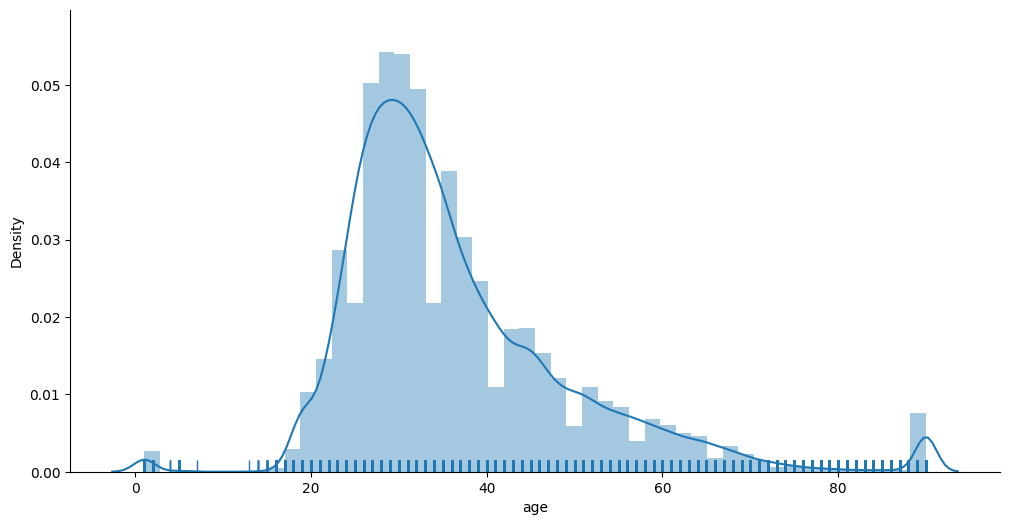

In [54]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.distplot(df.age.dropna(), rug=True)
sns.despine()

As expected, the most common age of Airbnb users is between 25 and 40. There are still too many nulls in age column. We are going to set the missing values equal to the median at 33. Before doing that, we create a new column for age_group.

In [55]:
df['age_group'] = df.age.map(lambda x: 0 if math.isnan(x) else (
                                       1 if x < 18 else (
                                       2 if x <= 32 else (
                                       3 if x <= 42 else 4))))

In [56]:
df.age = df.age.fillna(33)

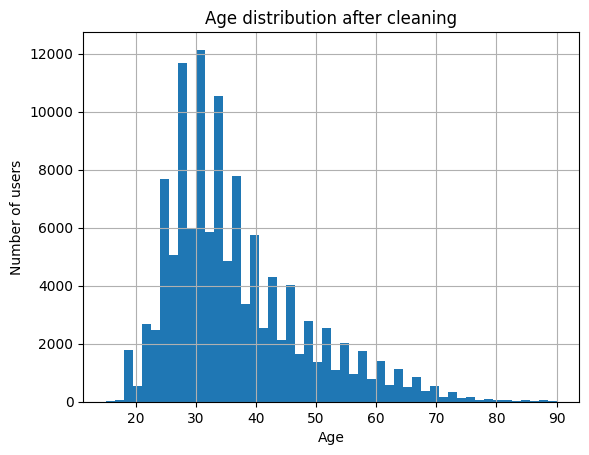

In [57]:
train.age.hist(bins=50, range=(15,90))
plt.xlabel("Age")
plt.ylabel("Number of users")
plt.title("Age distribution after cleaning")
plt.show()


### Users gender

In [58]:
df.gender.value_counts()

gender
-unknown-    129480
FEMALE        77524
MALE          68209
OTHER           334
Name: count, dtype: int64

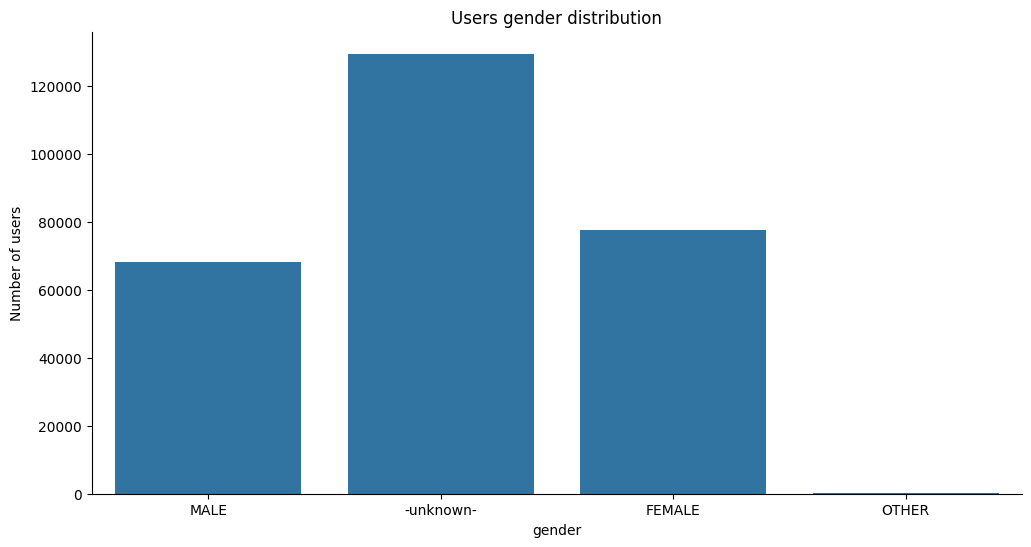

In [59]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='gender')
plt.ylabel('Number of users')
plt.title('Users gender distribution')
sns.despine()

Approx. 45% of users' gender were not presented. And there is no significant difference between female and male users on Airbnb's platform.

### Travel Destination Country

This is what we will predict in the test data.

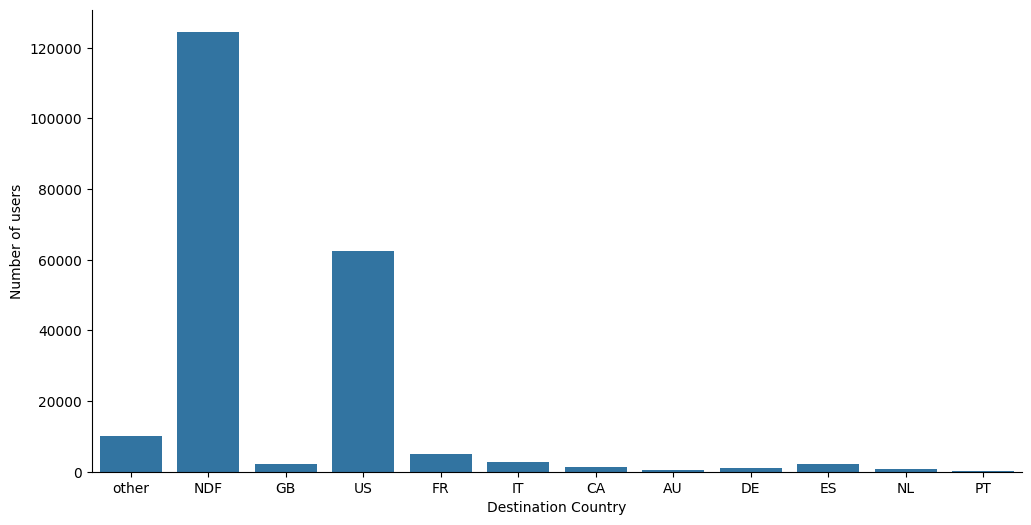

In [60]:
plt.figure(figsize=(12,6))
sns.countplot(x='country_destination', data=df.reset_index(drop=True))
plt.xlabel('Destination Country')
plt.ylabel('Number of users')
sns.despine()

C:\Users\ralma\AppData\Local\Temp\ipykernel_16500\3637710793.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


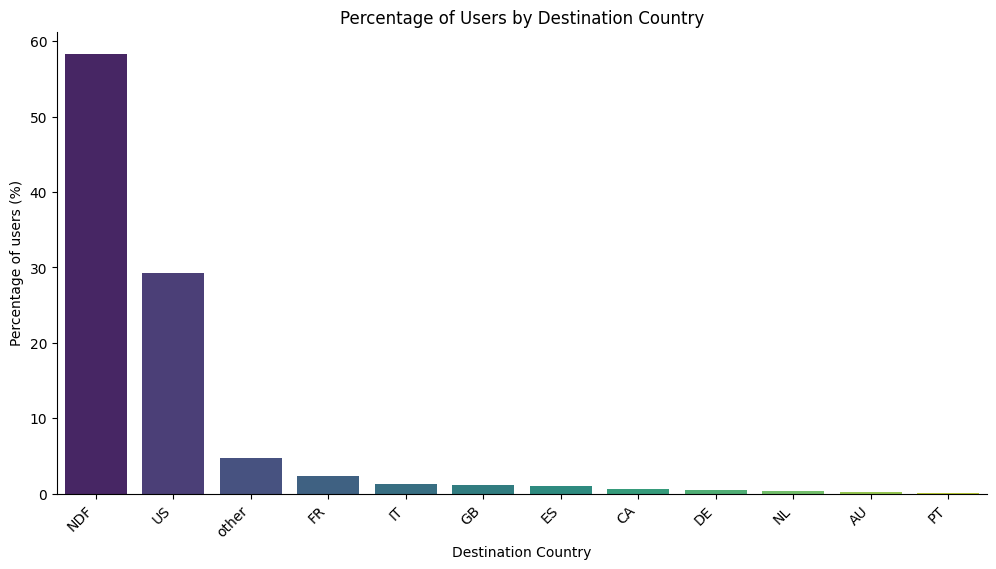

,country_destination,percentage
0,NDF,58.347349
1,US,29.222632
2,other,4.728954
3,FR,2.353233
4,IT,1.328174
5,GB,1.088774
6,ES,1.053638
7,CA,0.669006
8,DE,0.497070
9,NL,0.356991


In [61]:
# Simple version: works directly with country_destination column
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Compute percentages directly from the dataframe
# Use 'df' if available, otherwise try 'train'
if 'df' in globals() and 'country_destination' in df.columns:
    country_data = df['country_destination']
elif 'train' in globals() and 'country_destination' in train.columns:
    country_data = train['country_destination']
else:
    raise NameError("Could not find 'country_destination' column in 'df' or 'train'. Make sure the dataframe is loaded.")

country_pct = (
    country_data
    .value_counts(normalize=True) * 100
).reset_index()
country_pct.columns = ['country_destination', 'percentage']

# Plot
plt.figure(figsize=(12,6))
sns.barplot(
    x='country_destination',
    y='percentage',
    data=country_pct,
    palette='viridis'
)
plt.xlabel('Destination Country')
plt.ylabel('Percentage of users (%)')
plt.title('Percentage of Users by Destination Country')
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.show()

# Print table
display(country_pct)


Nearly 60% of users did not book any destination (NDF). The most booked country is the US (nearly 30% of all users booked US), given all users in the data set are from the US. We can say that US travelers in the dataset are more likely to travel within the US.

### signup_method

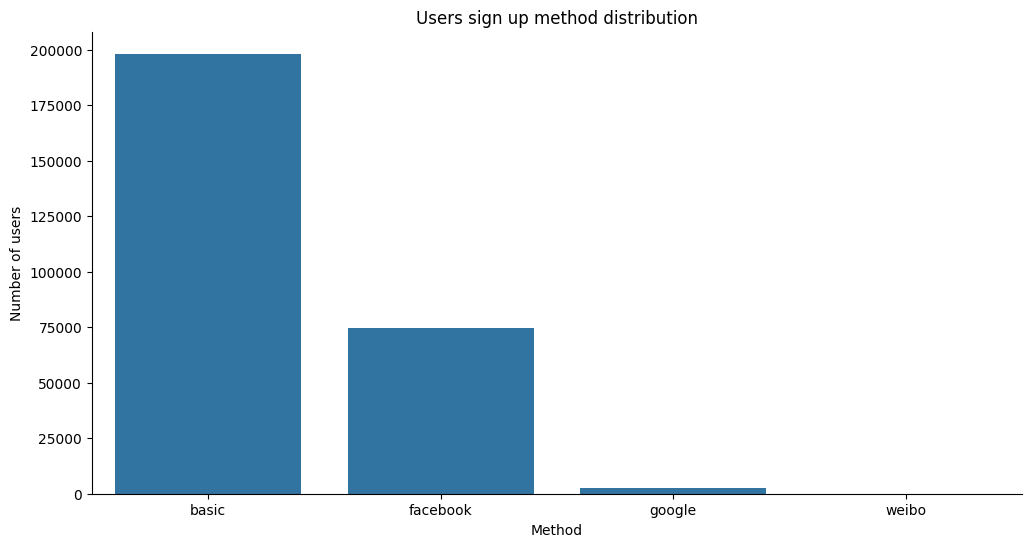

In [62]:
plt.figure(figsize=(12,6))
df_without_NDF = df[df['country_destination']!='NDF']
sns.countplot(x='signup_method', data=df.reset_index(drop=True))
plt.xlabel('Method')
plt.ylabel('Number of users')
plt.title('Users sign up method distribution')
sns.despine()

Over 70% of all users in the data used basic email method to sign up with Airbnb, and less than 30% of bookers used their facebook account to sign up, approx. only 0.26% of the bookers in the data used their Google accounts to sign up.

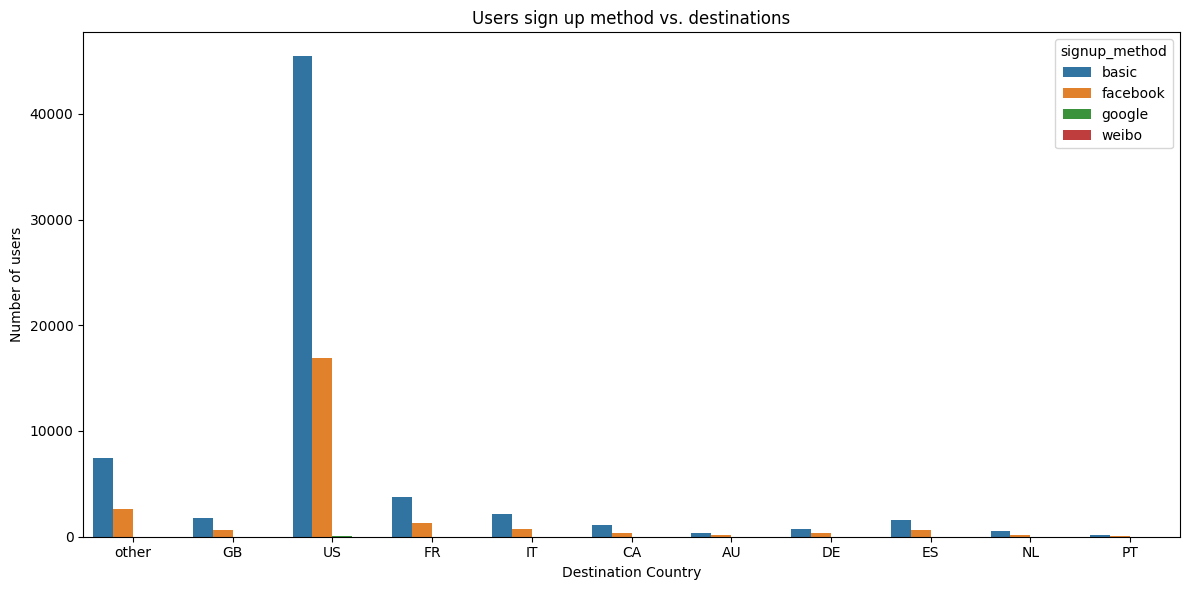

In [63]:
plt.figure(figsize=(12,6))

df_without_NDF1 = (
    df.loc[df['country_destination'] != 'NDF', ['country_destination', 'signup_method']]
      .copy()
      .reset_index(drop=True)
)

sns.countplot(data=df_without_NDF1, x='country_destination', hue='signup_method')
plt.xlabel('Destination Country')
plt.ylabel('Number of users')
plt.title('Users sign up method vs. destinations')
plt.tight_layout()
plt.show()

For users who made booking at least once, most of them signed up with Airbnb through basic email method, no matter which country they were travelling to.

### signup_app

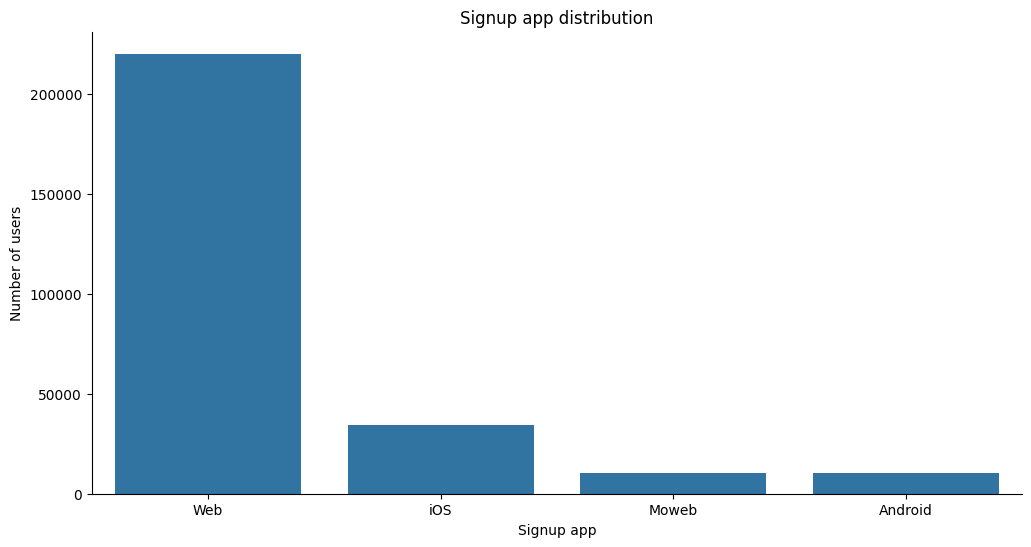

In [64]:
plt.figure(figsize=(12,6))
sns.countplot(x='signup_app', data=df)
plt.xlabel('Signup app')
plt.ylabel('Number of users')
plt.title('Signup app distribution')
sns.despine()

Over 85% of all bookers in the data set signed up on Airbnb's website, over 10% of all bookers signed up with iOs.

has signup_app: True
['key_0', 'id', 'date_account_created', 'timestamp_first_active', 'gender', 'age', 'signup_method', 'signup_flow', 'language', 'affiliate_channel', 'affiliate_provider', 'first_affiliate_tracked', 'signup_app', 'first_device_type', 'first_browser', 'country_destination', 'action_count', 'action', 'action_type', 'action_detail']


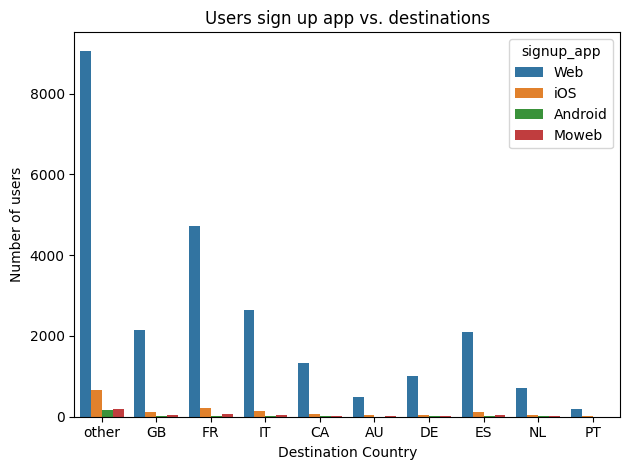

In [65]:
print('has signup_app:', 'signup_app' in df.columns)
print(df.columns.tolist()[:20])  # peek

# ensure clean index before plotting and avoid duplicate index labels
df_without_NDF_US = (
    df_without_NDF[df_without_NDF['country_destination']!='US']
      .copy()
      .reset_index(drop=True)
)

sns.countplot(data=df_without_NDF_US, x='country_destination', hue='signup_app')
plt.xlabel('Destination Country')
plt.ylabel('Number of users')
plt.title('Users sign up app vs. destinations')
plt.tight_layout()
plt.show()

Signing up through Airbnb website is the most common sign up on users no matter which destination country they travel to in the data.

### first_device_type

In [66]:
print(df.columns.tolist())

['key_0', 'id', 'date_account_created', 'timestamp_first_active', 'gender', 'age', 'signup_method', 'signup_flow', 'language', 'affiliate_channel', 'affiliate_provider', 'first_affiliate_tracked', 'signup_app', 'first_device_type', 'first_browser', 'country_destination', 'action_count', 'action', 'action_type', 'action_detail', 'device_type', 'unique_actions', 'unique_action_types', 'unique_action_details', 'unique_device_types', 'secs_elapsed_sum', 'secs_elapsed_mean', 'secs_elapsed_min', 'secs_elapsed_max', 'secs_elapsed_median', 'day_pauses', 'long_pauses', 'short_pauses', 'session_length', 'apple_device', 'desktop_device', 'tablet_device', 'mobile_device', 'age_group']


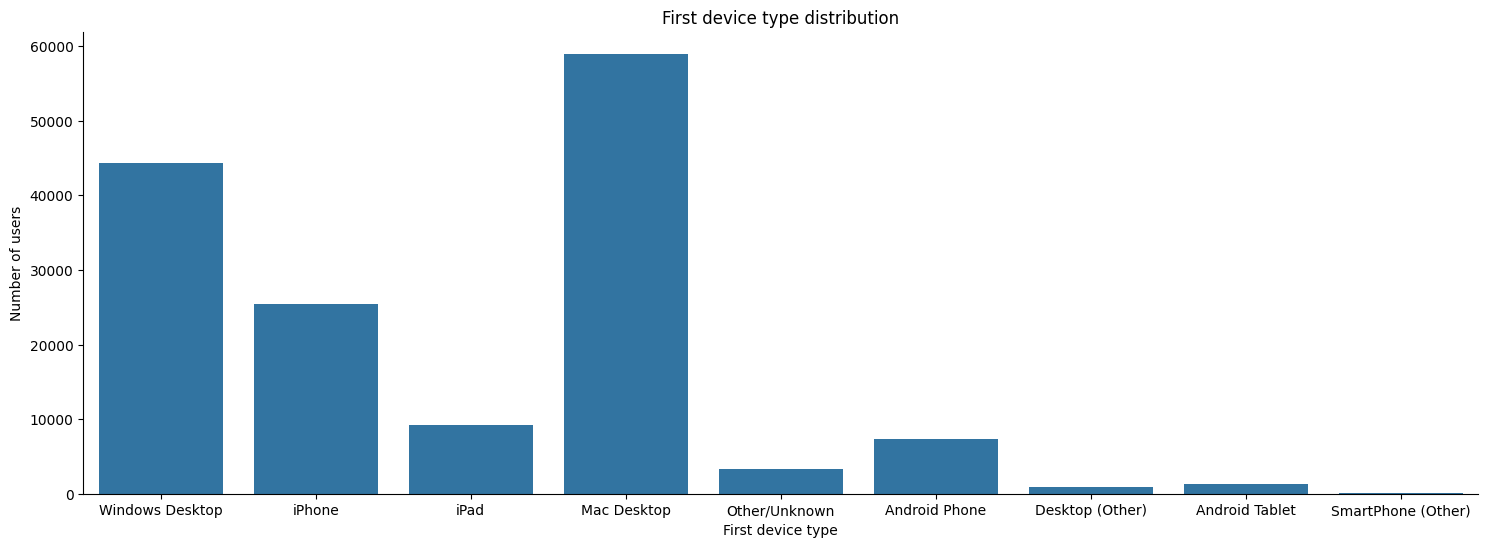

In [67]:
plt.figure(figsize=(18,6))
sns.countplot(data=df_without_NDF, x='first_device_type')
plt.xlabel('First device type')
plt.ylabel('Number of users')
plt.title('First device type distribution')
sns.despine()

In [68]:
print(df_without_NDF.columns.tolist())

['key_0', 'id', 'date_account_created', 'timestamp_first_active', 'gender', 'age', 'signup_method', 'signup_flow', 'language', 'affiliate_channel', 'affiliate_provider', 'first_affiliate_tracked', 'signup_app', 'first_device_type', 'first_browser', 'country_destination', 'action_count', 'action', 'action_type', 'action_detail', 'device_type', 'unique_actions', 'unique_action_types', 'unique_action_details', 'unique_device_types', 'secs_elapsed_sum', 'secs_elapsed_mean', 'secs_elapsed_min', 'secs_elapsed_max', 'secs_elapsed_median', 'day_pauses', 'long_pauses', 'short_pauses', 'session_length', 'apple_device', 'desktop_device', 'tablet_device', 'mobile_device', 'age_group']


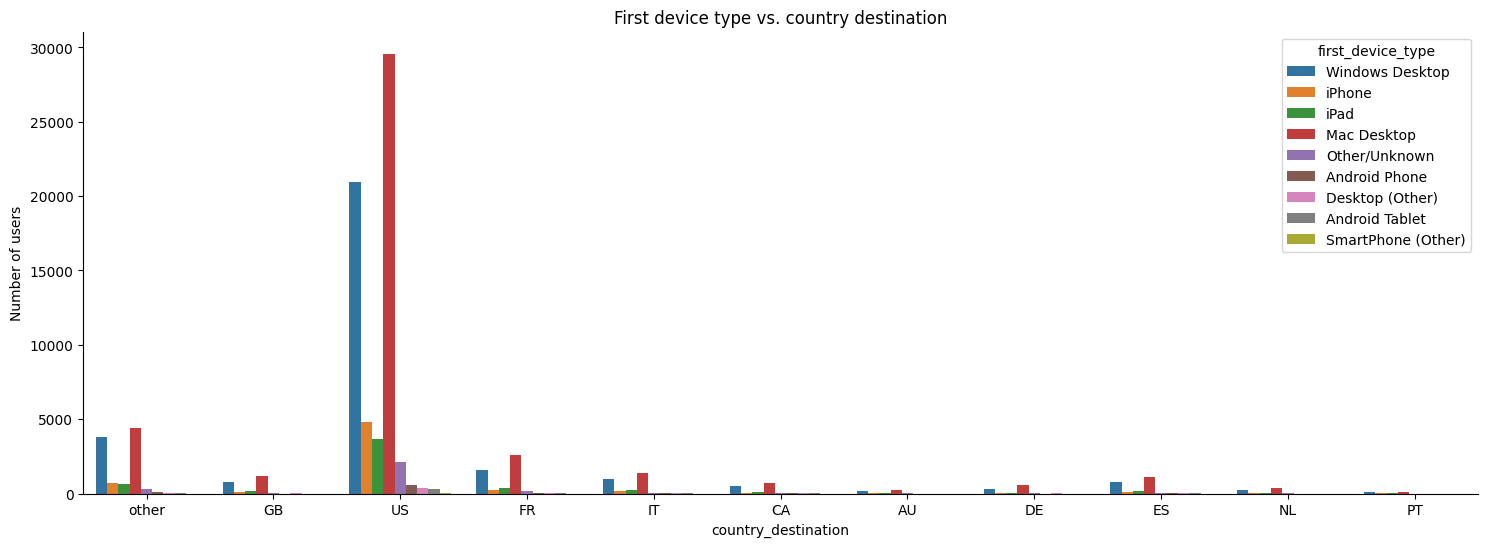

In [69]:
df_without_NDF = df_without_NDF.reset_index(drop=True)

plt.figure(figsize=(18,6))
sns.countplot(x='country_destination', data=df_without_NDF, hue='first_device_type')
plt.ylabel('Number of users')
plt.title('First device type vs. country destination')
sns.despine()

Around 60% of bookers use Apple devices. Particularly in the US.

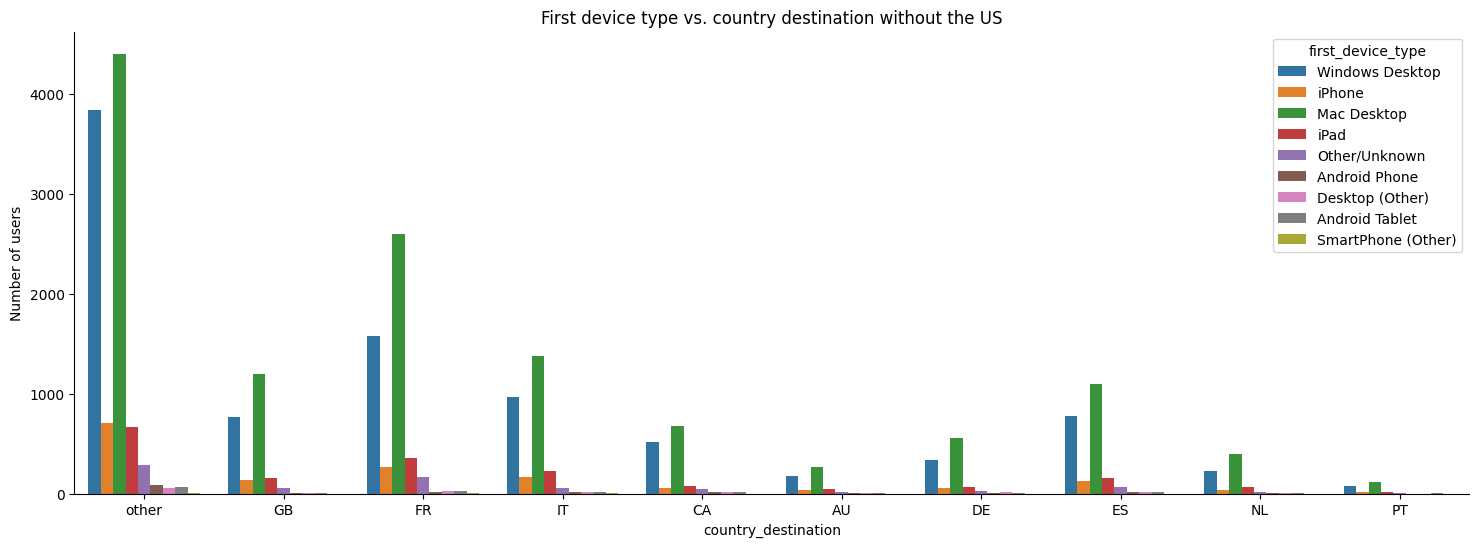

In [70]:
plt.figure(figsize=(18,6))
sns.countplot(x='country_destination', data=df_without_NDF_US, hue='first_device_type')
plt.ylabel('Number of users')
plt.title('First device type vs. country destination without the US')
sns.despine()

However, outside of the US, Windows descktop is far more common, in particular, there was little usage difference between Mac desktop and Windows desktop in Canada and Australia.

### Users preferred language

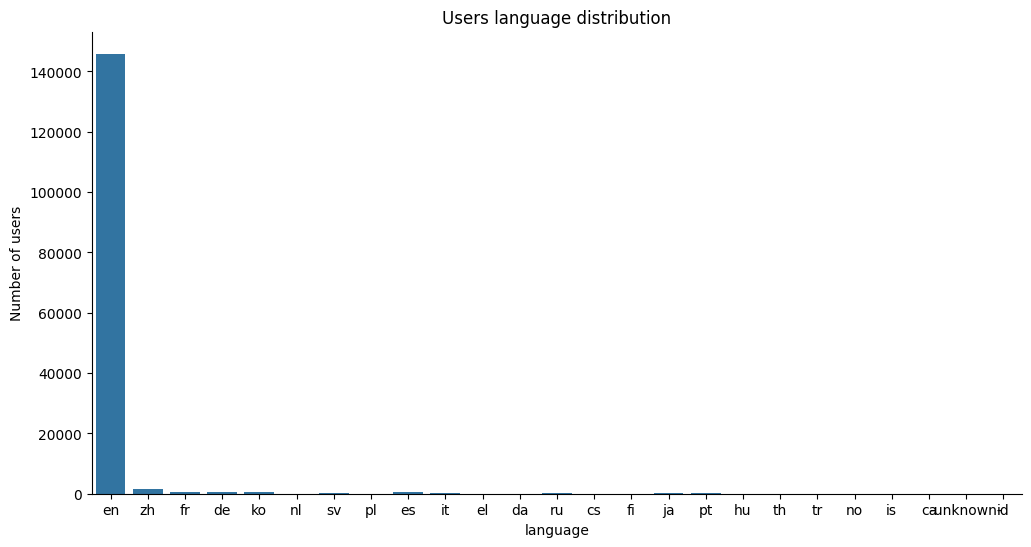

In [71]:
plt.figure(figsize=(12,6))
sns.countplot(x='language', data=df_without_NDF)
plt.xlabel('language')
plt.ylabel('Number of users')
plt.title('Users language distribution')
sns.despine()

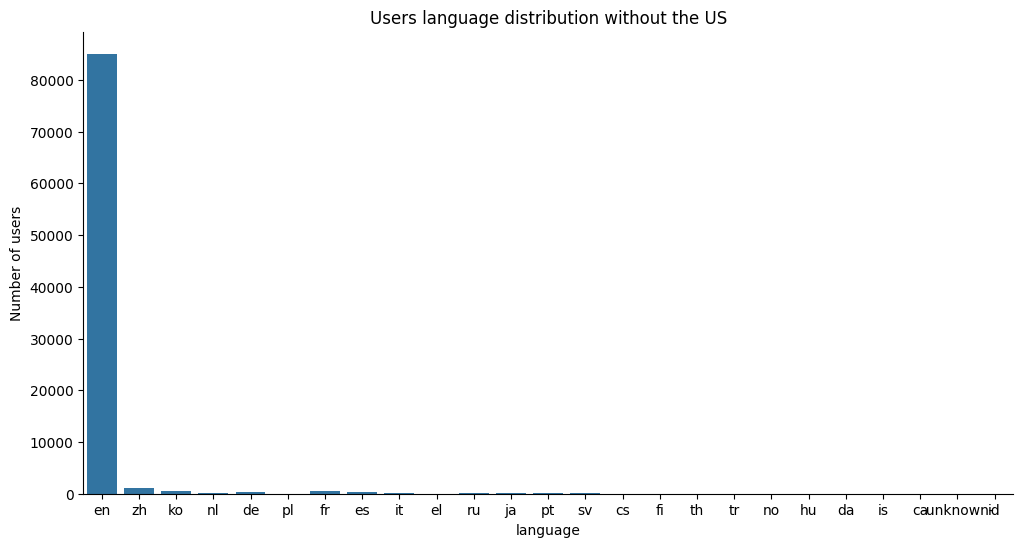

In [72]:
plt.figure(figsize=(12,6))
sns.countplot(x='language', data=df_without_NDF_US)
plt.xlabel('language')
plt.ylabel('Number of users')
plt.title('Users language distribution without the US')
sns.despine()

Even without the US, English is still the most preferred langauge, interestingly, Chinese is the 2nd most preferred languages for bookers.

### Date time features

Cast date columns to the correct data type and check to see they make sense.

In [73]:
df['date_account_created'] = pd.to_datetime(df['date_account_created'])
df['timestamp_first_active'] = pd.to_datetime((df.timestamp_first_active // 1000000), format='%Y%m%d')

print(df.timestamp_first_active.min())
print(df.timestamp_first_active.max())
print('---')
print(df.date_account_created.min())
print(df.date_account_created.max())

2009-03-19 00:00:00
2014-09-30 00:00:00
---
2010-01-01 00:00:00
2014-09-30 00:00:00


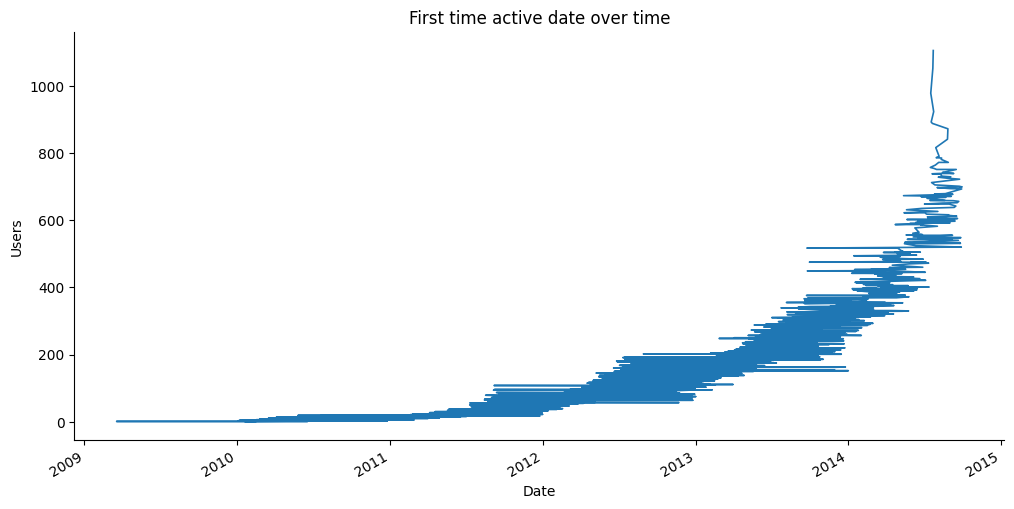

In [74]:
plt.figure(figsize=(12,6))
df.timestamp_first_active.value_counts().plot(kind='line', linewidth=1.2)
plt.xlabel('Date')
plt.ylabel('Users')
plt.title('First time active date over time')
sns.despine()

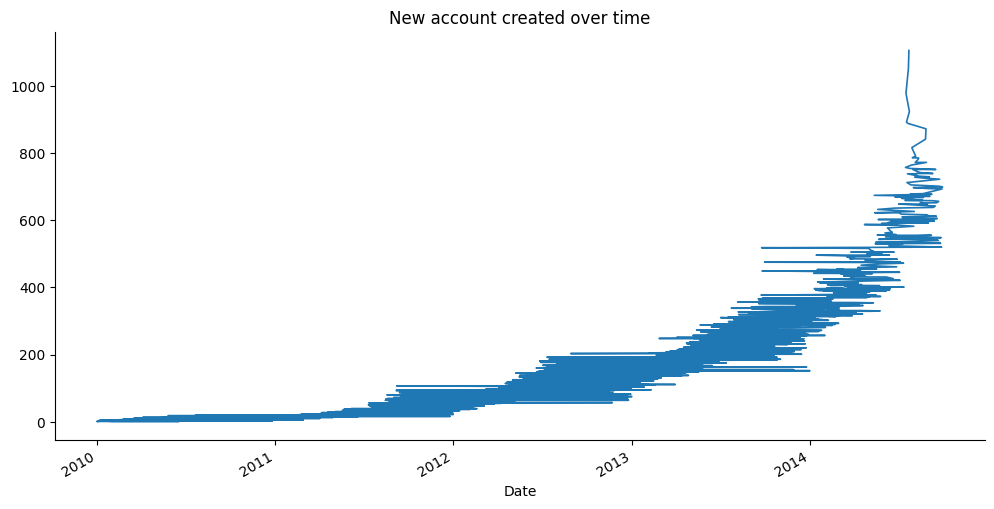

In [75]:
plt.figure(figsize=(12,6))
df.date_account_created.value_counts().plot(kind='line', linewidth=1.2)
plt.xlabel('Date')
plt.title('New account created over time')
sns.despine()

The pattern looks very similar between date account created and date first active, as it shoule be. From these two plots, we can see how fast Airbnb has grown since 2014.

### US Holidays

In [76]:
calendar = USFederalHolidayCalendar()
# Set holidays equal to the holidays in our date range.
holidays = calendar.holidays(start = df.timestamp_first_active.min(), 
                             end = df.timestamp_first_active.max())

# us_bd contains more years of information than we need.
us_bd = CustomBusinessDay(calendar = USFederalHolidayCalendar())
# Set business_days equal to the work days in our date range.
business_days = pd.date_range(start = df.timestamp_first_active.min(), 
                              end = df.timestamp_first_active.max(), 
                              freq = us_bd)

Create new date time features such as year, month, day of week, is business day, and is holiday.

In [77]:
df['year_account_created'] = df.date_account_created.dt.year
df['month_account_created'] = df.date_account_created.dt.month
df['weekday_account_created'] = df.date_account_created.dt.weekday
df['business_day_account_created'] = df.date_account_created.isin(business_days)
df['business_day_account_created'] = df.business_day_account_created.map(lambda x: 1 if x == True else 0)
df['holiday_account_created'] = df.date_account_created.isin(holidays)
df['holiday_account_created'] = df.holiday_account_created.map(lambda x: 1 if x == True else 0)

df['year_first_active'] = df.timestamp_first_active.dt.year
df['month_first_active'] = df.timestamp_first_active.dt.month
df['weekday_first_active'] = df.timestamp_first_active.dt.weekday
df['business_day_first_active'] = df.timestamp_first_active.isin(business_days)
df['business_day_first_active'] = df.business_day_first_active.map(lambda x: 1 if x == True else 0)
df['holiday_first_active'] = df.timestamp_first_active.isin(holidays)
df['holiday_first_active'] = df.holiday_first_active.map(lambda x: 1 if x == True else 0)

# Drop unneeded features
df = df.drop(["key_0","timestamp_first_active","date_account_created"], axis = 1)

In [78]:
df.head()

,id,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,...,year_account_created,month_account_created,weekday_account_created,business_day_account_created,holiday_account_created,year_first_active,month_first_active,weekday_first_active,business_day_first_active,holiday_first_active
0,d1mm9tcy42,MALE,62.0,basic,0,en,sem-non-brand,google,omg,Web,...,2014,1,2,0,1,2014,1,2,0,1
1,yo8nz8bqcq,-unknown-,33.0,basic,0,en,direct,direct,untracked,Web,...,2014,1,2,0,1,2014,1,2,0,1
2,4grx6yxeby,-unknown-,33.0,basic,0,en,sem-brand,google,omg,Web,...,2014,1,2,0,1,2014,1,2,0,1
3,ncf87guaf0,-unknown-,33.0,basic,0,en,direct,direct,linked,Web,...,2014,1,2,0,1,2014,1,2,0,1
4,4rvqpxoh3h,-unknown-,33.0,basic,25,en,direct,direct,untracked,iOS,...,2014,1,2,0,1,2014,1,2,0,1


In [79]:
df.isnull().sum()

id                                  0
gender                              0
age                                 0
signup_method                       0
signup_flow                         0
language                            0
affiliate_channel                   0
affiliate_provider                  0
first_affiliate_tracked          6085
signup_app                          0
first_device_type                   0
first_browser                       0
country_destination             62096
action_count                        0
action                              0
action_type                         0
action_detail                       0
device_type                         0
unique_actions                      0
unique_action_types                 0
unique_action_details               0
unique_device_types                 0
secs_elapsed_sum                    0
secs_elapsed_mean                   0
secs_elapsed_min                    0
secs_elapsed_max                    0
secs_elapsed

### first_affiliate_tracked

In [80]:
df['first_affiliate_tracked'].value_counts()

first_affiliate_tracked
untracked        143181
linked            62064
omg               54859
tracked-other      6655
product            2353
marketing           281
local ops            69
Name: count, dtype: int64

Set the missing values for "first_affiliate_tracked" to "untracked".

In [81]:
df.first_affiliate_tracked = df.first_affiliate_tracked.fillna("untracked")

In [82]:
# df.isnull().sum()
df.isnull().sum()[df.isnull().sum() > 0]

country_destination    62096
dtype: int64

The null values in 'country_destination' belong to the testing data. Now let's explore the categorical features that might have too many values and reduce that number before we do one-hot encoding.

#### first_browser_value_count

In [83]:
df.first_browser.value_counts()

first_browser
Chrome                  78671
Safari                  53302
-unknown-               44394
Firefox                 38665
Mobile Safari           29636
IE                      24744
Chrome Mobile            3186
Android Browser          1577
AOL Explorer              254
Opera                     228
Silk                      172
IE Mobile                 118
BlackBerry Browser         89
Chromium                   83
Mobile Firefox             64
Maxthon                    60
Apple Mail                 45
Sogou Explorer             43
SiteKiosk                  27
Iron                       24
RockMelt                   24
IceWeasel                  14
Yandex.Browser             14
Pale Moon                  13
CometBird                  12
SeaMonkey                  12
Camino                      9
Opera Mini                  8
TenFourFox                  8
wOSBrowser                  7
CoolNovo                    6
Opera Mobile                4
Avant Browser             

In [84]:
# Create a new feature for those using mobile browsers
mobile_browsers = ['Mobile Safari','Chrome Mobile','IE Mobile','Mobile Firefox','Android Browser']
df.loc[df.first_browser.isin(mobile_browsers), "first_browser"] = "Mobile"
# The cut_off is set at 2000. If a value is less than 2000, it will be grouped "other"
cut_off = 2000

other_browsers = []
for browser, count in df.first_browser.value_counts().items():
    if count < cut_off:
        other_browsers.append(browser)
df.loc[df.first_browser.isin(other_browsers), "first_browser"] = "Other"
df.first_browser.value_counts()

first_browser
Chrome       78671
Safari       53302
-unknown-    44394
Firefox      38665
Mobile       34581
IE           24744
Other         1190
Name: count, dtype: int64

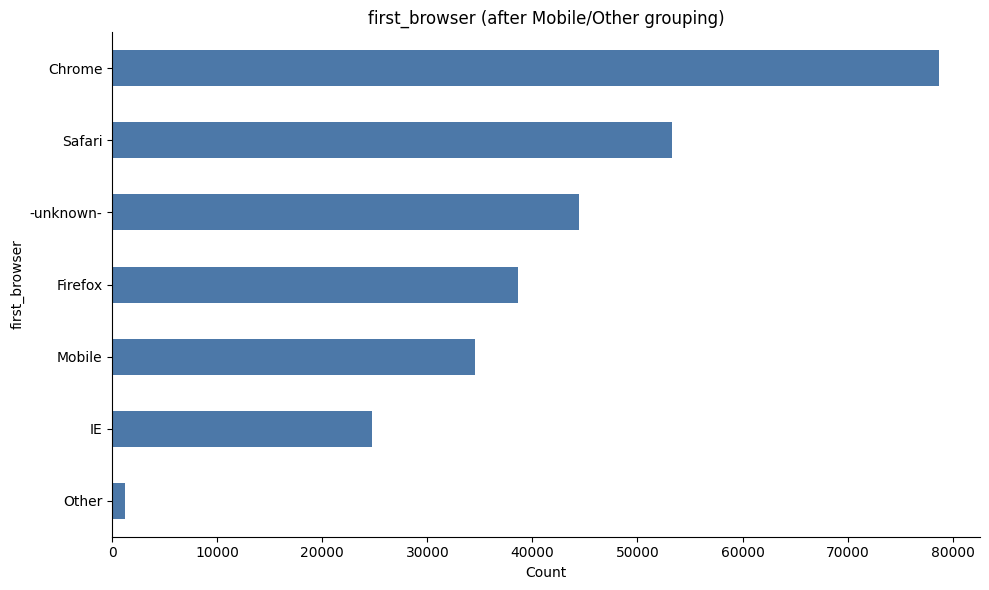

In [85]:
plt.figure(figsize=(10,6))
df.first_browser.value_counts().sort_values().plot(kind='barh', color='#4C78A8')
plt.title('first_browser (after Mobile/Other grouping)')
plt.xlabel('Count')
sns.despine(); plt.tight_layout()

#### language

In [86]:
df.language.value_counts()

language
en           265538
zh             2634
fr             1508
es             1174
ko             1116
de              977
it              633
ru              508
ja              345
pt              322
sv              176
nl              134
tr               92
da               75
pl               75
no               51
cs               49
el               30
th               28
hu               25
id               23
fi               20
ca                6
is                5
hr                2
-unknown-         1
Name: count, dtype: int64

In [ ]:
other_languages = []
for language, count in df.language.value_counts().items():
    if count < 200:
        other_languages.append(language)
df.loc[df.language.isin(other_languages), "language"] = "Other"   
df.language.value_counts()

language
en       265538
zh         2634
fr         1508
es         1174
ko         1116
de          977
Other       792
it          633
ru          508
ja          345
pt          322
Name: count, dtype: int64

In [88]:
# New feature for languages that are not English.
df['not_English'] = df.language.map(lambda x: 0 if x == 'en' else 1)

#### Action
Inspection of the distribution of user actions

In [89]:
df.action.value_counts()

action
missing                  140064
show                      61611
search_results            10368
index                      6493
dashboard                  5969
                          ...  
languages_multiselect         1
rate                          1
book                          1
salute                        1
view                          1
Name: count, Length: 170, dtype: int64

In [90]:
other_actions = []
for action, count in df.action.value_counts().items():
    if count < cut_off:
        other_actions.append(action)
df.loc[df.action.isin(other_actions), "action"] = "Other"
df.action.value_counts()

action
missing           140064
show               61611
Other              18967
search_results     10368
index               6493
dashboard           5969
search              5895
active              5836
update              5264
create              4259
requested           3574
edit                2714
authenticate        2277
personalize         2256
Name: count, dtype: int64

#### action_detail

In [91]:
df.action_detail.value_counts()

action_detail
missing                   140069
-unknown-                  35037
p3                         29387
view_search_results        28491
user_profile               10037
                           ...  
listing_descriptions           1
payment_instruments            1
airbnb_picks_wishlists         1
modify_users                   1
oauth_login                    1
Name: count, Length: 96, dtype: int64

In [92]:
other_action_details = []
for action_detail, count in df.action_detail.value_counts().items():
    if count < cut_off:
        other_action_details.append(action_detail)
df.loc[df.action_detail.isin(other_action_details), "action_detail"] = "Other"
df.action_detail.value_counts()

action_detail
missing                140069
-unknown-               35037
p3                      29387
view_search_results     28491
Other                   18125
user_profile            10037
dashboard                4893
update_listing           4463
header_userpic           2556
p5                       2489
Name: count, dtype: int64

#### action_type

In [93]:
df.action_type.value_counts()

action_type
missing             140070
view                 76491
click                18345
-unknown-            17724
data                 14750
submit                6485
message_post           998
track_page_view        316
partner_callback       134
booking_request        123
lookup                 109
modify                   2
Name: count, dtype: int64

In [94]:
other_action_types = []
for action_type, count in df.action_type.value_counts().items():
    if count < cut_off:
        other_action_types.append(action_type)
df.loc[df.action_type.isin(other_action_types), "action_type"] = "Other"
df.action_type.value_counts()

action_type
missing      140070
view          76491
click         18345
-unknown-     17724
data          14750
submit         6485
Other          1682
Name: count, dtype: int64

#### affiliate_provider

In [95]:
df.affiliate_provider.value_counts()

affiliate_provider
direct                 181270
google                  65956
other                   13036
facebook                 3996
bing                     3719
craigslist               3475
padmapper                 836
vast                      830
yahoo                     653
facebook-open-graph       566
gsp                       455
meetup                    358
email-marketing           270
naver                      66
baidu                      32
yandex                     18
wayn                        8
daum                        3
Name: count, dtype: int64

In [96]:
other_affiliate_providers = []
for affiliate_provider, count in df.affiliate_provider.value_counts().items():
    if count < cut_off:
        other_affiliate_providers.append(affiliate_provider)
df.loc[df.affiliate_provider.isin(other_affiliate_providers), "affiliate_provider"] = "other"
df.affiliate_provider.value_counts()

affiliate_provider
direct        181270
google         65956
other          17131
facebook        3996
bing            3719
craigslist      3475
Name: count, dtype: int64

#### device_type

In [97]:
df.device_type.value_counts()

device_type
missing                             140064
Mac Desktop                          44279
Windows Desktop                      37224
iPhone                               26567
iPad Tablet                           8880
Android Phone                         7670
-unknown-                             5792
Android App Unknown Phone/Tablet      2629
Tablet                                1469
Linux Desktop                          428
Chromebook                             374
iPodtouch                               86
Windows Phone                           56
Blackberry                              27
Opera Phone                              2
Name: count, dtype: int64

In [98]:
other_device_types = []
for device_type, count in df.device_type.value_counts().items():
    if count < cut_off:
        other_device_types.append(device_type)
df.loc[df.device_type.isin(other_device_types), "device_type"] = "Other"
df.device_type.value_counts()

device_type
missing                             140064
Mac Desktop                          44279
Windows Desktop                      37224
iPhone                               26567
iPad Tablet                           8880
Android Phone                         7670
-unknown-                             5792
Android App Unknown Phone/Tablet      2629
Other                                 2442
Name: count, dtype: int64

In [99]:
df.signup_method.value_counts()

signup_method
basic       198222
facebook     74864
google        2438
weibo           23
Name: count, dtype: int64

In [100]:
labels = pd.DataFrame(df.country_destination)
df = df.drop("country_destination", axis = 1)

In [101]:
labels.head()

,country_destination
0,other
1,NDF
2,NDF
3,NDF
4,GB


In [102]:
df.drop('id', axis=1, inplace=True)

In [103]:
df.columns.to_list()

['gender',
 'age',
 'signup_method',
 'signup_flow',
 'language',
 'affiliate_channel',
 'affiliate_provider',
 'first_affiliate_tracked',
 'signup_app',
 'first_device_type',
 'first_browser',
 'action_count',
 'action',
 'action_type',
 'action_detail',
 'device_type',
 'unique_actions',
 'unique_action_types',
 'unique_action_details',
 'unique_device_types',
 'secs_elapsed_sum',
 'secs_elapsed_mean',
 'secs_elapsed_min',
 'secs_elapsed_max',
 'secs_elapsed_median',
 'day_pauses',
 'long_pauses',
 'short_pauses',
 'session_length',
 'apple_device',
 'desktop_device',
 'tablet_device',
 'mobile_device',
 'age_group',
 'year_account_created',
 'month_account_created',
 'weekday_account_created',
 'business_day_account_created',
 'holiday_account_created',
 'year_first_active',
 'month_first_active',
 'weekday_first_active',
 'business_day_first_active',
 'holiday_first_active',
 'not_English']

In [104]:
# Group all features as either continuous (cont) or categorical (cat)
cont_features = []
cat_features = []

for feature in df.columns:
    if df[feature].dtype == float or df[feature].dtype == int:
        cont_features.append(feature)
    elif df[feature].dtype == object:
        cat_features.append(feature)

# Check to ensure that we have all of the features
print(cat_features)
print('---')
print(cont_features)
print('---')
display(len(cat_features) + len(cont_features))
display(df.shape[1])

['gender', 'signup_method', 'language', 'affiliate_channel', 'affiliate_provider', 'first_affiliate_tracked', 'signup_app', 'first_device_type', 'first_browser', 'action', 'action_type', 'action_detail', 'device_type']
---
['age', 'signup_flow', 'action_count', 'unique_actions', 'unique_action_types', 'unique_action_details', 'unique_device_types', 'secs_elapsed_sum', 'secs_elapsed_mean', 'secs_elapsed_min', 'secs_elapsed_max', 'secs_elapsed_median', 'day_pauses', 'long_pauses', 'short_pauses', 'session_length', 'apple_device', 'desktop_device', 'tablet_device', 'mobile_device', 'age_group', 'business_day_account_created', 'holiday_account_created', 'business_day_first_active', 'holiday_first_active', 'not_English']
---


39

45

Converts each categorical variable into a set of 0/1 variables and replaces the original column with them.

In [105]:
for feature in cat_features:
    # Create dummies of each value of a categorical feature
    dummies = pd.get_dummies(df[feature], prefix = feature, drop_first = False)
    # Drop the unneeded feature
    df = df.drop(feature, axis = 1)
    df = pd.concat([df, dummies], axis=1)
    print("{} is complete".format(feature))

gender is complete
signup_method is complete
language is complete
affiliate_channel is complete
affiliate_provider is complete
first_affiliate_tracked is complete
signup_app is complete
first_device_type is complete
first_browser is complete
action is complete
action_type is complete
action_detail is complete
device_type is complete


Preprocessing continuous variables normalizin each continuous feature to the 0–1 range using min and max.

In [106]:
min_max_scaler = preprocessing.MinMaxScaler()
# Normalize the continuous features
for feature in cont_features:
    df.loc[:,feature] = min_max_scaler.fit_transform(df[[feature]])

C:\Users\ralma\AppData\Local\Temp\ipykernel_16500\1049369683.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0. 0. 0. ... 0. 0. 0.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:,feature] = min_max_scaler.fit_transform(df[[feature]])
C:\Users\ralma\AppData\Local\Temp\ipykernel_16500\1049369683.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1. 0. 0. ... 1. 0. 0.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:,feature] = min_max_scaler.fit_transform(df[[feature]])


In [107]:
# Split df into training and testing data
df_train = df[:len(train)]
df_test = df[len(train):]

# Shorten labels to length of the training data
y = labels[:len(train)]

In [108]:
df_train.shape

(213451, 132)

In [109]:
y.shape

(213451, 1)

In [114]:
import pandas as pd

# Set max rows to None (no limit)
pd.set_option('display.max_rows', None)

# Now display your dtypes
display(df_train.dtypes.to_frame("dtype"))

,dtype
age,float64
signup_flow,float64
action_count,float64
unique_actions,float64
unique_action_types,float64
unique_action_details,float64
unique_device_types,float64
secs_elapsed_sum,float64
secs_elapsed_mean,float64
secs_elapsed_min,float64


In [115]:
import pandas as pd

# Set max rows to None (no limit)
pd.set_option('display.max_rows', None)

# Now display your dtypes
df_train.head()

,age,signup_flow,action_count,unique_actions,unique_action_types,unique_action_details,unique_device_types,secs_elapsed_sum,secs_elapsed_mean,secs_elapsed_min,...,action_detail_view_search_results,device_type_-unknown-,device_type_Android App Unknown Phone/Tablet,device_type_Android Phone,device_type_Mac Desktop,device_type_Other,device_type_Windows Desktop,device_type_iPad Tablet,device_type_iPhone,device_type_missing
0,0.685393,0.0,0.046657,0.232877,0.636364,0.181818,0.333333,0.090631,0.029227,0.000039,...,False,False,False,False,False,False,True,False,False,False
1,0.359551,0.0,0.003306,0.095890,0.363636,0.145455,0.166667,0.005709,0.025981,0.000704,...,False,False,False,False,True,False,False,False,False,False
2,0.359551,0.0,0.005878,0.178082,0.545455,0.145455,0.333333,0.029972,0.076720,0.001036,...,False,False,False,False,False,False,True,False,False,False
3,0.359551,0.0,0.055841,0.260274,0.636364,0.236364,0.500000,0.098492,0.026538,0.000000,...,False,False,False,False,False,False,True,False,False,False
4,0.359551,1.0,0.002939,0.095890,0.090909,0.018182,0.166667,0.000340,0.001740,0.000411,...,False,False,False,False,False,False,False,False,True,False


Prepare X and y for training: flatten the target to 1D, drop target and ID columns from the features, and check that the shapes match.

In [ ]:
# y is currently a (n,1) dataframe/array → convert to 1D
y_1d = np.ravel(y)


# just a double check so we dont take the answers of model
drop_cols = [c for c in ['country_destination', 'id', 'key_0'] if c in df_train.columns]
X = df_train.drop(columns=drop_cols)

print(X.shape, y_1d.shape)


(213451, 132) (213451,)


In [117]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y_1d,
    test_size=0.2,
    random_state=42,
    stratify=y_1d
)


Logistic Regression as baseline to quicly see and compare with other models. class_weight='balanced' so the model pays more attention to minority destination classes.

In [118]:
from sklearn.linear_model import LogisticRegression

baseline = LogisticRegression(
    max_iter=200,
    n_jobs=-1,
    class_weight="balanced"   # helps imbalance
)

baseline.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [119]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

pred = baseline.predict(X_val)

print("Accuracy:", accuracy_score(y_val, pred))
print("Macro F1:", f1_score(y_val, pred, average="macro"))


Accuracy: 0.2964090791970205
Macro F1: 0.07069365279788577


In [120]:
print(classification_report(y_val, pred))

              precision    recall  f1-score   support

          AU       0.00      0.20      0.01       108
          CA       0.02      0.04      0.02       286
          DE       0.01      0.28      0.01       212
          ES       0.02      0.03      0.02       450
          FR       0.04      0.15      0.06      1005
          GB       0.03      0.01      0.02       465
          IT       0.01      0.04      0.02       567
         NDF       0.74      0.49      0.59     24909
          NL       0.00      0.02      0.01       152
          PT       0.00      0.21      0.01        43
          US       0.45      0.01      0.02     12475
       other       0.07      0.07      0.07      2019

    accuracy                           0.30     42691
   macro avg       0.12      0.13      0.07     42691
weighted avg       0.57      0.30      0.35     42691



These numbers show that the logistic regression baseline is not doing well on this task.

Accuracy 0.30 (30%) — About 1 in 3 predictions is correct. With ~12 destination classes and many NDFs (no booking), this is better than random, but not strong.

Macro F1 0.07 (7%) — The model is poor on most individual classes. Macro F1 averages F1 across all classes, so small classes matter as much as big ones. The low value indicates weak performance on minority destinations (FR, AU, ES, etc.).

In [123]:
from sklearn.metrics import recall_score

acc = accuracy_score(y_val, pred)
macro_f1 = f1_score(y_val, pred, average="macro")
weighted_f1 = f1_score(y_val, pred, average="weighted")
macro_recall = recall_score(y_val, pred, average="macro")


In [121]:
import numpy as np

proba = baseline.predict_proba(X_val)
classes = baseline.classes_

top5 = np.argsort(proba, axis=1)[:, -5:]          # indices of top5 classes
top5_labels = classes[top5]                        # convert indices → class labels

top5_acc = np.mean([y_val[i] in top5_labels[i] for i in range(len(y_val))])
print("Top-5 Accuracy:", top5_acc)


Top-5 Accuracy: 0.5527628774214706


In [124]:
from sklearn.metrics import ndcg_score
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
y_true_bin = lb.fit_transform(y_val)

ndcg5 = ndcg_score(y_true_bin, proba, k=5)


In [122]:
results = []


In [125]:
results.append({
    "Model": "Logistic Regression",
    "Accuracy": acc,
    "Macro_F1": macro_f1,
    "Weighted_F1": weighted_f1,
    "Macro_Recall": macro_recall,
    "Top5_Accuracy": top5_acc,
    "NDCG@5": ndcg5
})


In [126]:
results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.2964090791970205,
  'Macro_F1': 0.07069365279788577,
  'Weighted_F1': 0.35318365825343645,
  'Macro_Recall': 0.1287337535495786,
  'Top5_Accuracy': np.float64(0.5527628774214706),
  'NDCG@5': 0.4215418019346394}]

The model focuses on frequent classes (NDF, US) and does poorly on the rest. Top-5 Accuracy and NDCG@5 show it’s more useful as a ranking model (is the right country in the top 5?) than as a classifier (is the single top prediction correct?).

---------

This cell uses permutation importance to see which features matter for the model.

In [128]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    baseline, X_val, y_val,
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

feat_imp_perm = (
    pd.DataFrame({"feature": X.columns, "importance": perm.importances_mean})
      .sort_values("importance", ascending=False)
      .reset_index(drop=True)
)

feat_imp_perm.head(20)


,feature,importance
0,gender_-unknown-,0.054110
1,age_group,0.046958
2,gender_FEMALE,0.017545
3,gender_MALE,0.013891
4,apple_device,0.001593
5,first_affiliate_tracked_untracked,0.000828
6,action_detail_Other,0.000625
7,action_show,0.000617
8,first_browser_Chrome,0.000414
9,action_type_click,0.000359


Unknown often goes with NDF (no booking).

Age groups help separate destinations (e.g. younger vs older users).

Gender also matters, but less than unknown vs known.

gender (especially unknown) and age_group are the main drivers of the logistic model.
Session features (action, action_detail, action_type) contribute little.
Tree models likely do better because they can use interactions and non-linear effects, whereas logistic regression relies heavily on these few linear features.

# Modeling Roadmap

## Phase 1 — Strong Baseline Models
Train Linear SVM, XGBoost (GPU), LightGBM (GPU), CatBoost (GPU)

## Phase 2 — Select Best Single Models
Compare using Accuracy, Macro F1, Weighted F1, Macro Recall, Top-5, NDCG@5

## Phase 3 — Hierarchical 3-Step Model
1. Trip vs NDF  
2. US vs Other Countries  
3. Specific Country Prediction  
Combine probabilities

## Phase 4 — Imbalance Handling Experiments
Class Weights, Oversampling, Undersampling, SMOTE

## Phase 5 — Cross-Validation & Hyperparameter Tuning
Stratified K-Fold + Random Search / Optuna

## Phase 6 — Feature Importance & Selection
Permutation Importance + Feature Pruning

## Phase 7 — Final Optimization
Model Ensembling + Probability Calibration


In [129]:
from sklearn.svm import LinearSVC

svm = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm.fit(X_train, y_train)


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,42


In [130]:
pred_svm = svm.predict(X_val)


In [131]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

acc = accuracy_score(y_val, pred_svm)
macro_f1 = f1_score(y_val, pred_svm, average="macro")
weighted_f1 = f1_score(y_val, pred_svm, average="weighted")
macro_recall = recall_score(y_val, pred_svm, average="macro")

print("Accuracy:", acc)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)
print("Macro Recall:", macro_recall)


Accuracy: 0.44747136398772575
Macro F1: 0.07904531383460425
Weighted F1: 0.42368372666218274
Macro Recall: 0.11148320133169783


In [132]:
import numpy as np
from sklearn.metrics import ndcg_score
from sklearn.preprocessing import LabelBinarizer

scores = svm.decision_function(X_val)   # (n_samples, n_classes)
classes = svm.classes_

top5_idx = np.argsort(scores, axis=1)[:, -5:]
top5_labels = classes[top5_idx]
top5_acc = np.mean([y_val[i] in top5_labels[i] for i in range(len(y_val))])

lb = LabelBinarizer()
y_true_bin = lb.fit_transform(y_val)
ndcg5 = ndcg_score(y_true_bin, scores, k=5)

print("Top-5 Accuracy:", top5_acc)
print("NDCG@5:", ndcg5)


Top-5 Accuracy: 0.7109695251926635
NDCG@5: 0.5858307701505537


In [133]:
results.append({
    "Model": "Linear SVM (LinearSVC)",
    "Accuracy": acc,
    "Macro_F1": macro_f1,
    "Weighted_F1": weighted_f1,
    "Macro_Recall": macro_recall,
    "Top5_Accuracy": top5_acc,
    "NDCG@5": ndcg5
})


In [134]:
from sklearn.inspection import permutation_importance
import pandas as pd

perm = permutation_importance(
    svm, X_val, y_val,
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

feat_imp_svm = (pd.DataFrame({
    "feature": X.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)
  .reset_index(drop=True))

feat_imp_svm.head(20)


,feature,importance
0,year_account_created,0.126873
1,month_first_active,0.119604
2,month_account_created,0.116004
3,year_first_active,0.106166
4,affiliate_channel_direct,0.102910
5,affiliate_provider_direct,0.082781
6,weekday_first_active,0.057655
7,weekday_account_created,0.054578
8,first_device_type_Mac Desktop,0.045864
9,first_device_type_Windows Desktop,0.041656


In [136]:
results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.2964090791970205,
  'Macro_F1': 0.07069365279788577,
  'Weighted_F1': 0.35318365825343645,
  'Macro_Recall': 0.1287337535495786,
  'Top5_Accuracy': np.float64(0.5527628774214706),
  'NDCG@5': 0.4215418019346394},
 {'Model': 'Linear SVM (LinearSVC)',
  'Accuracy': 0.44747136398772575,
  'Macro_F1': 0.07904531383460425,
  'Weighted_F1': 0.42368372666218274,
  'Macro_Recall': 0.11148320133169783,
  'Top5_Accuracy': np.float64(0.7109695251926635),
  'NDCG@5': 0.5858307701505537}]

Accuracy, Top-5, NDCG@5, and Weighted F1 are noticeably higher. SVM is doing better at both exact and top‑5 predictions.
Macro F1 is only slightly higher; both models still struggle with minority classes.
Macro Recall is a bit lower; SVM may be more conservative on some classes.
NDCG@5 58.6% means the ranking of the top 5 destinations is clearly better than with Logistic Regression.

In [137]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=20,          # keeps it from overfitting too hard
    min_samples_leaf=50
)

dt.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,50
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [138]:
pred_dt = dt.predict(X_val)


In [139]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

acc = accuracy_score(y_val, pred_dt)
macro_f1 = f1_score(y_val, pred_dt, average="macro")
weighted_f1 = f1_score(y_val, pred_dt, average="weighted")
macro_recall = recall_score(y_val, pred_dt, average="macro")

print("Accuracy:", acc)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)
print("Macro Recall:", macro_recall)


Accuracy: 0.1513667986226605
Macro F1: 0.04970227103761718
Weighted F1: 0.22705188042685467
Macro Recall: 0.11185684822179139


In [140]:
import numpy as np
from sklearn.metrics import ndcg_score
from sklearn.preprocessing import LabelBinarizer

proba = dt.predict_proba(X_val)
classes = dt.classes_

top5_idx = np.argsort(proba, axis=1)[:, -5:]
top5_labels = classes[top5_idx]
top5_acc = np.mean([y_val[i] in top5_labels[i] for i in range(len(y_val))])

lb = LabelBinarizer()
y_true_bin = lb.fit_transform(y_val)
ndcg5 = ndcg_score(y_true_bin, proba, k=5)

print("Top-5 Accuracy:", top5_acc)
print("NDCG@5:", ndcg5)


Top-5 Accuracy: 0.7472066711953339
NDCG@5: 0.4470692776353646


In [141]:
results.append({
    "Model": "Decision Tree",
    "Accuracy": acc,
    "Macro_F1": macro_f1,
    "Weighted_F1": weighted_f1,
    "Macro_Recall": macro_recall,
    "Top5_Accuracy": top5_acc,
    "NDCG@5": ndcg5
})


In [142]:
from sklearn.inspection import permutation_importance
import pandas as pd

perm = permutation_importance(
    dt, X_val, y_val,
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

feat_imp_dt = (pd.DataFrame({
    "feature": X.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)
  .reset_index(drop=True))

feat_imp_dt.head(20)


,feature,importance
0,age_group,0.066048
1,signup_app_Web,0.041148
2,gender_-unknown-,0.036581
3,month_account_created,0.015991
4,signup_flow,0.015421
5,secs_elapsed_sum,0.014468
6,first_device_type_Other/Unknown,0.010080
7,secs_elapsed_min,0.007176
8,signup_method_basic,0.006293
9,action_count,0.005622


In [144]:
results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.2964090791970205,
  'Macro_F1': 0.07069365279788577,
  'Weighted_F1': 0.35318365825343645,
  'Macro_Recall': 0.1287337535495786,
  'Top5_Accuracy': np.float64(0.5527628774214706),
  'NDCG@5': 0.4215418019346394},
 {'Model': 'Linear SVM (LinearSVC)',
  'Accuracy': 0.44747136398772575,
  'Macro_F1': 0.07904531383460425,
  'Weighted_F1': 0.42368372666218274,
  'Macro_Recall': 0.11148320133169783,
  'Top5_Accuracy': np.float64(0.7109695251926635),
  'NDCG@5': 0.5858307701505537},
 {'Model': 'Decision Tree',
  'Accuracy': 0.1513667986226605,
  'Macro_F1': 0.04970227103761718,
  'Weighted_F1': 0.22705188042685467,
  'Macro_Recall': 0.11185684822179139,
  'Top5_Accuracy': np.float64(0.7472066711953339),
  'NDCG@5': 0.4470692776353646}]

 The tree is better at having the right country somewhere in the top 5, but worse at picking it as #1 and at producing reliable probabilities. That pattern is common for single trees: they can overfit and lack calibration. Gradient boosting (XGBoost, CatBoost, LightGBM) usually improves this by combining many trees.

In [145]:
# XGBoost (GPU)
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="gpu_hist",
    predictor="gpu_predictor",
    n_estimators=600,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42
)

xgb.fit(X_train, y_train)


ValueError: Invalid classes inferred from unique values of `y`.  Expected: [ 0  1  2  3  4  5  6  7  8  9 10 11], got ['AU' 'CA' 'DE' 'ES' 'FR' 'GB' 'IT' 'NDF' 'NL' 'PT' 'US' 'other']

In [146]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)


In [147]:
# XGBoost (GPU)
xgb = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="gpu_hist",
    predictor="gpu_predictor",
    n_estimators=600,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42
)

xgb.fit(X_train, y_train_enc)


C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:58:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:58:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [148]:
# XGBoost (GPU) predictions
pred_xgb = xgb.predict(X_val)
proba_xgb = xgb.predict_proba(X_val)


C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:2676: UserWarning: [17:00:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:
C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:729: UserWarning: [17:00:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only b

In [150]:
# XGBoost (GPU) metrics
from sklearn.metrics import accuracy_score, f1_score, recall_score, ndcg_score
import numpy as np
from sklearn.preprocessing import LabelBinarizer

pred_xgb = xgb.predict(X_val)          # numeric labels
proba_xgb = xgb.predict_proba(X_val)   # (n, n_classes)

acc = accuracy_score(y_val_enc, pred_xgb)
macro_f1 = f1_score(y_val_enc, pred_xgb, average="macro")
weighted_f1 = f1_score(y_val_enc, pred_xgb, average="weighted")
macro_recall = recall_score(y_val_enc, pred_xgb, average="macro")

top5_idx = np.argsort(proba_xgb, axis=1)[:, -5:]
top5_acc = np.mean([y_val_enc[i] in top5_idx[i] for i in range(len(y_val_enc))])

lb = LabelBinarizer()
y_true_bin = lb.fit_transform(y_val_enc)
ndcg5 = ndcg_score(y_true_bin, proba_xgb, k=5)

print("Accuracy:", acc)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)
print("Macro Recall:", macro_recall)
print("Top-5 Accuracy:", top5_acc)
print("NDCG@5:", ndcg5)


Accuracy: 0.6492937621512731
Macro F1: 0.10712520122041146
Weighted F1: 0.6008301633441735
Macro Recall: 0.11386962927520956
Top-5 Accuracy: 0.9579068187674217
NDCG@5: 0.8301366557741862


In [151]:
# Save XGBoost (GPU)
results.append({
    "Model": "XGBoost (GPU)",
    "Accuracy": acc,
    "Macro_F1": macro_f1,
    "Weighted_F1": weighted_f1,
    "Macro_Recall": macro_recall,
    "Top5_Accuracy": top5_acc,
    "NDCG@5": ndcg5
})


In [152]:
# XGBoost (GPU) feature importance (gain)
import pandas as pd

feat_imp_xgb = (pd.DataFrame({
    "feature": X.columns,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)
  .reset_index(drop=True))

feat_imp_xgb.head(20)


,feature,importance
0,signup_method_facebook,0.064729
1,age_group,0.056128
2,action_update,0.045552
3,action_requested,0.038890
4,affiliate_channel_content,0.024923
5,signup_method_basic,0.018083
6,action_detail_update_listing,0.014821
7,gender_-unknown-,0.014713
8,unique_action_types,0.013982
9,signup_app_Web,0.013085


In [153]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    xgb, X_val, y_val_enc,
    n_repeats=2,
    random_state=42,
    n_jobs=-1
)

feat_imp_xgb_perm = (pd.DataFrame({
    "feature": X.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)
  .reset_index(drop=True))

feat_imp_xgb_perm.head(20)


,feature,importance
0,age_group,0.122016
1,signup_method_facebook,0.020719
2,unique_action_types,0.011630
3,month_first_active,0.007098
4,signup_flow,0.006266
5,month_account_created,0.005844
6,signup_method_basic,0.003947
7,year_account_created,0.003596
8,gender_-unknown-,0.003092
9,age,0.002928


In [154]:
results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.2964090791970205,
  'Macro_F1': 0.07069365279788577,
  'Weighted_F1': 0.35318365825343645,
  'Macro_Recall': 0.1287337535495786,
  'Top5_Accuracy': np.float64(0.5527628774214706),
  'NDCG@5': 0.4215418019346394},
 {'Model': 'Linear SVM (LinearSVC)',
  'Accuracy': 0.44747136398772575,
  'Macro_F1': 0.07904531383460425,
  'Weighted_F1': 0.42368372666218274,
  'Macro_Recall': 0.11148320133169783,
  'Top5_Accuracy': np.float64(0.7109695251926635),
  'NDCG@5': 0.5858307701505537},
 {'Model': 'Decision Tree',
  'Accuracy': 0.1513667986226605,
  'Macro_F1': 0.04970227103761718,
  'Weighted_F1': 0.22705188042685467,
  'Macro_Recall': 0.11185684822179139,
  'Top5_Accuracy': np.float64(0.7472066711953339),
  'NDCG@5': 0.4470692776353646},
 {'Model': 'XGBoost (GPU)',
  'Accuracy': 0.6492937621512731,
  'Macro_F1': 0.10712520122041146,
  'Weighted_F1': 0.6008301633441735,
  'Macro_Recall': 0.11386962927520956,
  'Top5_Accuracy': np.float64(0.957906

In [155]:
# LightGBM (GPU)
import lightgbm as lgb

lgbm = lgb.LGBMClassifier(
    objective="multiclass",
    n_estimators=800,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    device="gpu",
    random_state=42
)

lgbm.fit(X_train, y_train_enc)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2609
[LightGBM] [Info] Number of data points in the train set: 170760, number of used features: 131
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 18 dense feature groups (3.26 MB) transferred to GPU in 0.019861 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[L

,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.05
,n_estimators,800
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [156]:
# LightGBM (GPU) predictions
pred_lgb = lgbm.predict(X_val)
proba_lgb = lgbm.predict_proba(X_val)


In [157]:
# LightGBM (GPU) metrics
from sklearn.metrics import accuracy_score, f1_score, recall_score, ndcg_score
import numpy as np
from sklearn.preprocessing import LabelBinarizer

acc = accuracy_score(y_val_enc, pred_lgb)
macro_f1 = f1_score(y_val_enc, pred_lgb, average="macro")
weighted_f1 = f1_score(y_val_enc, pred_lgb, average="weighted")
macro_recall = recall_score(y_val_enc, pred_lgb, average="macro")

top5_idx = np.argsort(proba_lgb, axis=1)[:, -5:]
top5_acc = np.mean([y_val_enc[i] in top5_idx[i] for i in range(len(y_val_enc))])

lb = LabelBinarizer()
y_true_bin = lb.fit_transform(y_val_enc)
ndcg5 = ndcg_score(y_true_bin, proba_lgb, k=5)

print("Accuracy:", acc)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)
print("Macro Recall:", macro_recall)
print("Top-5 Accuracy:", top5_acc)
print("NDCG@5:", ndcg5)


Accuracy: 0.47600196762783725
Macro F1: 0.11522245681415762
Weighted F1: 0.5295222340123437
Macro Recall: 0.12340170659179739
Top-5 Accuracy: 0.896184207444192
NDCG@5: 0.6997072083386197


In [158]:
# Save LightGBM (GPU)
results.append({
    "Model": "LightGBM (GPU)",
    "Accuracy": acc,
    "Macro_F1": macro_f1,
    "Weighted_F1": weighted_f1,
    "Macro_Recall": macro_recall,
    "Top5_Accuracy": top5_acc,
    "NDCG@5": ndcg5
})


LightGBM is stronger on minority classes: higher Macro F1 (11.5% vs 10.7%) and Macro Recall (12.3% vs 11.4%).
XGBoost is stronger overall: higher Accuracy, Weighted F1, Top-5, and NDCG@5.
LightGBM may need different hyperparameters (e.g. learning rate, number of leaves) or more tuning to reach XGBoost’s level on these metrics.
For a ranking task, NDCG@5 matters most, and XGBoost (83%) is clearly better than LightGBM (70%) here.

In [159]:
# LightGBM feature importance
import pandas as pd

feat_imp_lgb = (pd.DataFrame({
    "feature": X.columns,
    "importance": lgbm.feature_importances_
}).sort_values("importance", ascending=False)
  .reset_index(drop=True))

feat_imp_lgb.head(20)


,feature,importance
0,age,75089
1,month_account_created,34370
2,month_first_active,31847
3,weekday_account_created,30257
4,weekday_first_active,21850
5,secs_elapsed_median,21318
6,secs_elapsed_mean,18698
7,secs_elapsed_max,18546
8,secs_elapsed_sum,15971
9,secs_elapsed_min,15724


In [161]:
# CatBoost (GPU)
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=800,
    learning_rate=0.05,
    depth=8,
    loss_function="MultiClass",
    eval_metric="MultiClass",
    task_type="GPU",
    verbose=0,
    random_state=42
)

cat.fit(X_train, y_train_enc)


In [162]:
# CatBoost predictions
pred_cat = cat.predict(X_val).astype(int).ravel()
proba_cat = cat.predict_proba(X_val)


In [163]:
# CatBoost (GPU) metrics
from sklearn.metrics import accuracy_score, f1_score, recall_score, ndcg_score
import numpy as np
from sklearn.preprocessing import LabelBinarizer

acc = accuracy_score(y_val_enc, pred_cat)
macro_f1 = f1_score(y_val_enc, pred_cat, average="macro")
weighted_f1 = f1_score(y_val_enc, pred_cat, average="weighted")
macro_recall = recall_score(y_val_enc, pred_cat, average="macro")

top5_idx = np.argsort(proba_cat, axis=1)[:, -5:]
top5_acc = np.mean([y_val_enc[i] in top5_idx[i] for i in range(len(y_val_enc))])

lb = LabelBinarizer()
y_true_bin = lb.fit_transform(y_val_enc)
ndcg5 = ndcg_score(y_true_bin, proba_cat, k=5)

print("Accuracy:", acc)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)
print("Macro Recall:", macro_recall)
print("Top-5 Accuracy:", top5_acc)
print("NDCG@5:", ndcg5)


Accuracy: 0.6487081586282823
Macro F1: 0.10680357717478528
Weighted F1: 0.5997785387935164
Macro Recall: 0.11355799505658178
Top-5 Accuracy: 0.9584689981494928
NDCG@5: 0.8303585058601491


CatBoost and XGBoost are almost the same on every metric.
CatBoost is slightly ahead on Top-5 (95.85%) and NDCG@5 (83.04%); the rest are marginally lower.
Both are clearly better than Logistic Regression, Linear SVM, Decision Tree, and LightGBM.

In [164]:
# Save CatBoost (GPU)
results.append({
    "Model": "CatBoost (GPU)",
    "Accuracy": acc,
    "Macro_F1": macro_f1,
    "Weighted_F1": weighted_f1,
    "Macro_Recall": macro_recall,
    "Top5_Accuracy": top5_acc,
    "NDCG@5": ndcg5
})


In [165]:
# CatBoost feature importance
import pandas as pd

feat_imp_cat = (pd.DataFrame({
    "feature": X.columns,
    "importance": cat.get_feature_importance()
}).sort_values("importance", ascending=False)
  .reset_index(drop=True))

feat_imp_cat.head(20)


,feature,importance
0,age,8.079619
1,age_group,7.570917
2,month_first_active,4.986773
3,month_account_created,3.655462
4,secs_elapsed_median,3.210131
5,secs_elapsed_min,3.065430
6,unique_action_types,2.953477
7,year_account_created,2.726711
8,weekday_account_created,2.706673
9,secs_elapsed_mean,2.698113


### Hyperparameter Tuning (Small Controlled Upgrade)

In [171]:
%pip install optuna catboost

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.1 MB 1.1 MB/s eta 0:00:02
   -------------- ------------------------- 0.8/2.1 MB 1.2 MB/s eta 0:00:02
   ------------------- -------------------- 1.0/2.1 MB 1.2 MB/s eta 0:00:01
   ------------------------ --------------- 1.3/2.1 MB 1.2 MB/s eta 0:00:01
   ----------------------------- ---------- 1.6/2.1 MB 1.2 MB/s eta 0:00:01
   ---------------------------------- ----- 1.8/2.1 MB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 1.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Users\ralma\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [172]:
# Optuna + CatBoost (GPU)
import optuna
from catboost import CatBoostClassifier


Optuna automatically searches CatBoost hyperparameters and picks settings that maximize NDCG@5 on the validation set.

In [173]:
# Objective: maximize NDCG@5 on validation
from sklearn.metrics import ndcg_score
from sklearn.preprocessing import LabelBinarizer
import numpy as np

lb = LabelBinarizer()
y_val_bin = lb.fit_transform(y_val_enc)

def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 400, 1200),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
        "depth": trial.suggest_int("depth", 6, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 20.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.0, 2.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "loss_function": "MultiClass",
        "task_type": "GPU",
        "verbose": 0,
        "random_state": 42
    }

    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train_enc)

    proba = model.predict_proba(X_val)
    return ndcg_score(y_val_bin, proba, k=5)


In [174]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

study.best_value, study.best_params


[I 2026-02-17 17:37:43,352] A new study created in memory with name: no-name-4116d590-5a45-401f-9524-0376c1e34325
[I 2026-02-17 17:38:23,163] Trial 0 finished with value: 0.8305468824255189 and parameters: {'iterations': 468, 'learning_rate': 0.033515973472708065, 'depth': 10, 'l2_leaf_reg': 13.474434884973684, 'random_strength': 1.825059374990402, 'bagging_temperature': 0.3487027816293268}. Best is trial 0 with value: 0.8305468824255189.
[I 2026-02-17 17:38:55,416] Trial 1 finished with value: 0.8305983821900986 and parameters: {'iterations': 697, 'learning_rate': 0.02593085978609139, 'depth': 8, 'l2_leaf_reg': 8.29339963198447, 'random_strength': 1.5421824123540537, 'bagging_temperature': 0.2129754644370795}. Best is trial 1 with value: 0.8305983821900986.
[I 2026-02-17 17:39:23,576] Trial 2 finished with value: 0.8303756273427673 and parameters: {'iterations': 627, 'learning_rate': 0.022904185733559988, 'depth': 8, 'l2_leaf_reg': 5.601513199366612, 'random_strength': 0.2041227571128

(0.8308975783979228,
 {'iterations': 705,
  'learning_rate': 0.08634642846884609,
  'depth': 6,
  'l2_leaf_reg': 2.6545525611739733,
  'random_strength': 1.2400542964022807,
  'bagging_temperature': 0.13104236981616113})

In [175]:
# Best CatBoost from Optuna
best_cat = CatBoostClassifier(
    **study.best_params,
    loss_function="MultiClass",
    task_type="GPU",
    verbose=0,
    random_state=42
)

best_cat.fit(X_train, y_train_enc)


In [176]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

pred = best_cat.predict(X_val).astype(int).ravel()
proba = best_cat.predict_proba(X_val)

acc = accuracy_score(y_val_enc, pred)
macro_f1 = f1_score(y_val_enc, pred, average="macro")
weighted_f1 = f1_score(y_val_enc, pred, average="weighted")
macro_recall = recall_score(y_val_enc, pred, average="macro")

top5 = np.argsort(proba, axis=1)[:, -5:]
top5_acc = np.mean([y_val_enc[i] in top5[i] for i in range(len(y_val_enc))])

ndcg5 = ndcg_score(y_val_bin, proba, k=5)

results.append({
    "Model": "CatBoost (GPU) Optuna",
    "Accuracy": acc,
    "Macro_F1": macro_f1,
    "Weighted_F1": weighted_f1,
    "Macro_Recall": macro_recall,
    "Top5_Accuracy": top5_acc,
    "NDCG@5": ndcg5
})

print(acc, macro_f1, weighted_f1, macro_recall, top5_acc, ndcg5)


0.6490126724602375 0.1068829304784235 0.6000680108509568 0.11363483185676289 0.9590780258134033 0.8307131107125617


Compared with default CatBoost (64.87% Acc, 83.04% NDCG@5), tuning gives a small gain in NDCG@5 (83.07%) and Top-5 (95.91%), so the search improved the ranking slightly.

In [192]:
# Save CatBoost Optuna results
results.append({
    "Model": "CatBoost (GPU) Optuna",
    "Accuracy": acc,
    "Macro_F1": macro_f1,
    "Weighted_F1": weighted_f1,
    "Macro_Recall": macro_recall,
    "Top5_Accuracy": float(top5_acc),
    "NDCG@5": ndcg5
})


In [179]:
study.best_value

0.8308975783979228

In [177]:
import pandas as pd

feat_imp_cat_optuna = (pd.DataFrame({
    "feature": X.columns,
    "importance": best_cat.get_feature_importance()
}).sort_values("importance", ascending=False)
  .reset_index(drop=True))

feat_imp_cat_optuna.head(20)


,feature,importance
0,age_group,12.021081
1,age,7.357489
2,month_first_active,4.355426
3,month_account_created,3.613201
4,unique_action_types,3.425919
5,signup_method_facebook,3.282479
6,secs_elapsed_min,3.274676
7,signup_flow,3.128866
8,year_account_created,3.084106
9,secs_elapsed_median,2.850355


Step A is a binary classifier: will the user book a trip or not? Step B (US vs other) and Step C (specific country) are trained only on users who have a trip (where Step A predicts 1).

In [180]:
# Step A target: 1 = Trip, 0 = NDF
y_stepA = (y_train_enc != le.transform(["NDF"])[0]).astype(int)
y_val_stepA = (y_val_enc != le.transform(["NDF"])[0]).astype(int)


In [181]:
# Step A Model (Binary CatBoost GPU)
from catboost import CatBoostClassifier

model_A = CatBoostClassifier(
    iterations=600,
    learning_rate=0.05,
    depth=8,
    loss_function="Logloss",
    task_type="GPU",
    verbose=0,
    random_state=42
)

model_A.fit(X_train, y_stepA)


In [182]:
# Get Trip-only indices
trip_idx_train = y_stepA == 1
trip_idx_val = y_val_stepA == 1

X_train_B = X_train[trip_idx_train]
X_val_B = X_val[trip_idx_val]

y_train_B = y_train_enc[trip_idx_train]
y_val_B = y_val_enc[trip_idx_val]


In [183]:
us_label = le.transform(["US"])[0]

y_train_stepB = (y_train_B == us_label).astype(int)
y_val_stepB = (y_val_B == us_label).astype(int)


In [184]:
model_B = CatBoostClassifier(
    iterations=600,
    learning_rate=0.05,
    depth=8,
    loss_function="Logloss",
    task_type="GPU",
    verbose=0,
    random_state=42
)

model_B.fit(X_train_B, y_train_stepB)


In [185]:
non_us_idx_train = (y_train_B != us_label)
non_us_idx_val = (y_val_B != us_label)

X_train_C = X_train_B[non_us_idx_train]
X_val_C = X_val_B[non_us_idx_val]

y_train_C = y_train_B[non_us_idx_train]
y_val_C = y_val_B[non_us_idx_val]


In [186]:
model_C = CatBoostClassifier(
    iterations=800,
    learning_rate=0.05,
    depth=8,
    loss_function="MultiClass",
    task_type="GPU",
    verbose=0,
    random_state=42
)

model_C.fit(X_train_C, y_train_C)


In [187]:
# Hierarchical CatBoost: get probabilities
import numpy as np

# Step A: P(trip)
p_trip = model_A.predict_proba(X_val)[:, 1]          # shape (n,)

# Step B: P(US | trip) only for trip-val rows
p_us_given_trip = model_B.predict_proba(X_val_B)[:, 1]   # shape (n_trip_val,)

# Step C: P(country | trip & nonUS) only for nonUS-trip-val rows
proba_C = model_C.predict_proba(X_val_C)             # shape (n_nonUS_trip_val, n_classes_C)
classes_C = model_C.classes_


In [188]:
# Hierarchical CatBoost: combine into final proba over all classes
n_val = X_val.shape[0]
n_classes = len(le.classes_)
final_proba = np.zeros((n_val, n_classes), dtype=float)

ndf_label = le.transform(["NDF"])[0]
us_label = le.transform(["US"])[0]

# P(NDF)
final_proba[:, ndf_label] = 1 - p_trip

# Fill trip rows: P(US) and P(other countries)
val_trip_rows = np.where(trip_idx_val)[0]
val_nonus_rows = np.where(trip_idx_val)[0][non_us_idx_val]   # trip rows that are non-US

# US prob for trip rows
final_proba[val_trip_rows, us_label] = p_trip[val_trip_rows] * p_us_given_trip

# other countries mass for trip rows
p_other_mass = p_trip[val_trip_rows] * (1 - p_us_given_trip)

# distribute other-mass across Step C classes (only for non-US trip rows)
# map Step C probs into the correct global class columns
for j, cls in enumerate(classes_C):
    final_proba[val_nonus_rows, cls] = p_other_mass[non_us_idx_val] * proba_C[:, j]


In [189]:
# Hierarchical CatBoost: metrics
from sklearn.metrics import accuracy_score, f1_score, recall_score, ndcg_score
from sklearn.preprocessing import LabelBinarizer

pred_h = np.argmax(final_proba, axis=1)

acc = accuracy_score(y_val_enc, pred_h)
macro_f1 = f1_score(y_val_enc, pred_h, average="macro")
weighted_f1 = f1_score(y_val_enc, pred_h, average="weighted")
macro_recall = recall_score(y_val_enc, pred_h, average="macro")

top5_idx = np.argsort(final_proba, axis=1)[:, -5:]
top5_acc = np.mean([y_val_enc[i] in top5_idx[i] for i in range(len(y_val_enc))])

lb = LabelBinarizer()
y_val_bin = lb.fit_transform(y_val_enc)
ndcg5 = ndcg_score(y_val_bin, final_proba, k=5)

print("Accuracy:", acc)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)
print("Macro Recall:", macro_recall)
print("Top-5 Accuracy:", top5_acc)
print("NDCG@5:", ndcg5)


Accuracy: 0.7307395001288328
Macro F1: 0.1199184769980008
Weighted F1: 0.6670439500685635
Macro Recall: 0.12533066132264528
Top-5 Accuracy: 0.9590546016724837
NDCG@5: 0.860954352789331


Large gain in accuracy (64.9% → 73.1%): the hierarchical setup improves the top-1 prediction.

Noticeable gain in NDCG@5 (83.1% → 86.1%): better ranking of the top 5 destinations.

Better minority-class performance: Macro F1 and Macro Recall both rise.

Top-5 stays similar (~96%), so both are already very strong there.

In [193]:
# Save Hierarchical model
results.append({
    "Model": "Hierarchical CatBoost (A:Trip/NDF, B:US/Other, C:Country)",
    "Accuracy": acc,
    "Macro_F1": macro_f1,
    "Weighted_F1": weighted_f1,
    "Macro_Recall": macro_recall,
    "Top5_Accuracy": top5_acc,
    "NDCG@5": ndcg5
})


In [191]:
# Feature importance for Step C (country prediction among non-US trips)
import pandas as pd

feat_imp_h_C = (pd.DataFrame({
    "feature": X.columns,
    "importance": model_C.get_feature_importance()
}).sort_values("importance", ascending=False)
  .reset_index(drop=True))

feat_imp_h_C.head(20)


,feature,importance
0,age,9.026511
1,month_first_active,6.959693
2,weekday_account_created,4.508610
3,weekday_first_active,4.217388
4,month_account_created,3.978212
5,secs_elapsed_median,3.354526
6,gender_MALE,3.076116
7,gender_FEMALE,3.073923
8,secs_elapsed_max,2.961577
9,secs_elapsed_min,2.939808


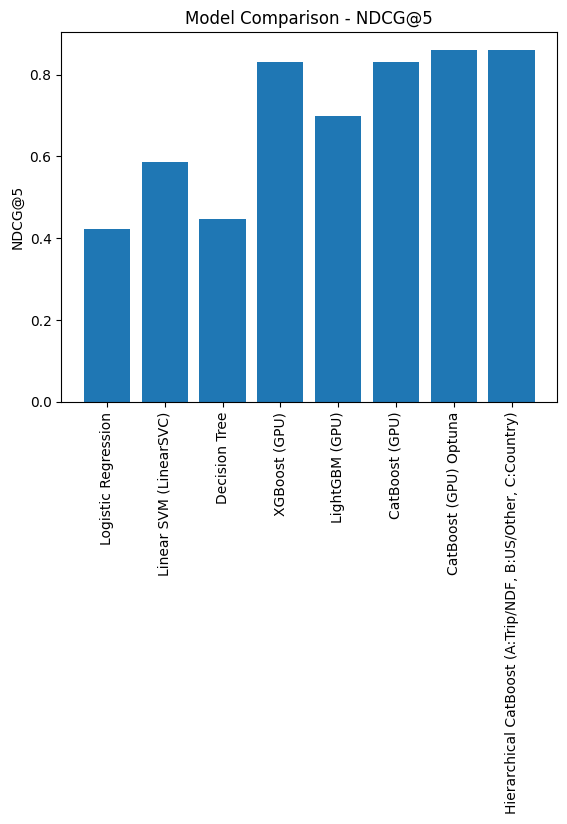

In [202]:
results# Plot NDCG@5 for all models
import matplotlib.pyplot as plt
import pandas as pd

df_results = pd.DataFrame(results)

plt.figure()
plt.bar(df_results["Model"], df_results["NDCG@5"])
plt.xticks(rotation=90)
plt.title("Model Comparison - NDCG@5")
plt.ylabel("NDCG@5")
plt.show()


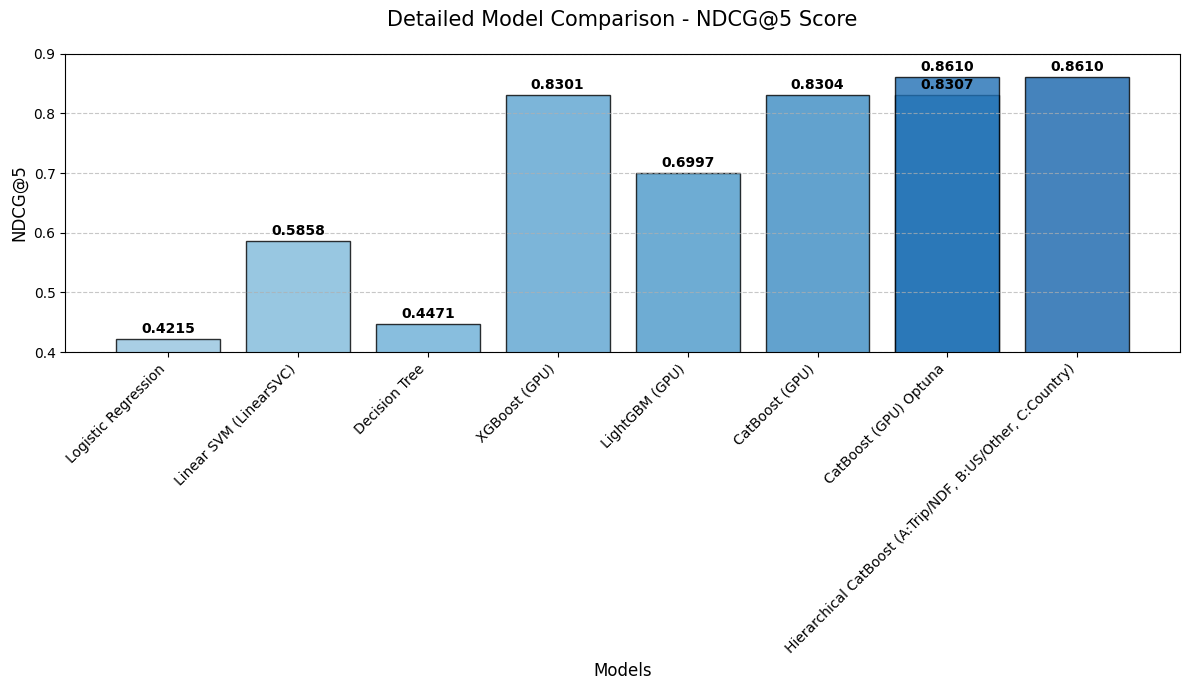

In [204]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


df_results = pd.DataFrame(results)
plt.figure(figsize=(12, 7))
colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(df_results)))
bars = plt.bar(df_results["Model"], df_results["NDCG@5"], color=colors, edgecolor='black', alpha=0.8)
plt.ylim(0.4, 0.9)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, 
             f'{yval:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
plt.xticks(rotation=45, ha='right')
plt.title("Detailed Model Comparison - NDCG@5 Score", fontsize=15, pad=20)
plt.ylabel("NDCG@5", fontsize=12)
plt.xlabel("Models", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

### 

In [211]:
results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.2964090791970205,
  'Macro_F1': 0.07069365279788577,
  'Weighted_F1': 0.35318365825343645,
  'Macro_Recall': 0.1287337535495786,
  'Top5_Accuracy': np.float64(0.5527628774214706),
  'NDCG@5': 0.4215418019346394},
 {'Model': 'Linear SVM (LinearSVC)',
  'Accuracy': 0.44747136398772575,
  'Macro_F1': 0.07904531383460425,
  'Weighted_F1': 0.42368372666218274,
  'Macro_Recall': 0.11148320133169783,
  'Top5_Accuracy': np.float64(0.7109695251926635),
  'NDCG@5': 0.5858307701505537},
 {'Model': 'Decision Tree',
  'Accuracy': 0.1513667986226605,
  'Macro_F1': 0.04970227103761718,
  'Weighted_F1': 0.22705188042685467,
  'Macro_Recall': 0.11185684822179139,
  'Top5_Accuracy': np.float64(0.7472066711953339),
  'NDCG@5': 0.4470692776353646},
 {'Model': 'XGBoost (GPU)',
  'Accuracy': 0.6492937621512731,
  'Macro_F1': 0.10712520122041146,
  'Weighted_F1': 0.6008301633441735,
  'Macro_Recall': 0.11386962927520956,
  'Top5_Accuracy': np.float64(0.957906

### Create Hybrid Sampling Strategy

The cell sets desired class sizes for resampling: it cuts NDF to 35% and US to 25% of the training set, and lifts each minority class to about 4%. That setup is used for undersampling and SMOTE so the model sees a more balanced mix of destinations instead of mostly NDF and US.

In [214]:
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import numpy as np

# Current counts
y_series = pd.Series(y_train_enc)
class_counts = y_series.value_counts()

ndf_label = le.transform(["NDF"])[0]
us_label = le.transform(["US"])[0]

# Define target counts manually
target_counts = {}

total = len(y_train_enc)

# Reduce NDF to 35%
target_counts[ndf_label] = int(0.35 * total)

# Reduce US to 25%
target_counts[us_label] = int(0.25 * total)

# For all others, raise them moderately
for cls in class_counts.index:
    if cls not in [ndf_label, us_label]:
        target_counts[cls] = int(0.04 * total)  # around 4% each

target_counts


{np.int64(7): 59765,
 np.int64(10): 42690,
 11: 6830,
 4: 6830,
 6: 6830,
 5: 6830,
 3: 6830,
 1: 6830,
 2: 6830,
 8: 6830,
 0: 6830,
 9: 6830}

In [215]:
from imblearn.under_sampling import RandomUnderSampler

ndf_label = le.transform(["NDF"])[0]
us_label  = le.transform(["US"])[0]

rus = RandomUnderSampler(
    sampling_strategy={ndf_label: int(0.35*len(y_train_enc)),
                       us_label:  int(0.25*len(y_train_enc))},
    random_state=42
)

X_u, y_u = rus.fit_resample(X_train, y_train_enc)


In [216]:
from imblearn.over_sampling import SMOTE
import numpy as np

counts = pd.Series(y_u).value_counts()
target_minor = int(0.04*len(y_train_enc))  # mild growth

smote_strategy = {cls: target_minor for cls in counts.index
                  if cls not in [ndf_label, us_label] and counts[cls] < target_minor}

sm = SMOTE(sampling_strategy=smote_strategy, random_state=42, k_neighbors=5)
X_hybrid, y_hybrid = sm.fit_resample(X_u, y_u)

print("Before:", X_train.shape)
print("After :", X_hybrid.shape)


Before: (170760, 132)
After : (172000, 132)


The hybrid sampling added 1,240 rows (170,760 → 172,000) by oversampling minority classes with SMOTE

In [217]:
pd.Series(le.inverse_transform(y_hybrid)).value_counts(normalize=True).mul(100).round(2)


NDF      34.75
US       24.82
other     4.69
AU        3.97
ES        3.97
DE        3.97
CA        3.97
FR        3.97
IT        3.97
GB        3.97
PT        3.97
NL        3.97
Name: proportion, dtype: float64

Before : 

NDF = 58%

US = 29%

Smallest = 0.1%

AFTER: NDF 34.75% and US 24.82%
NDF and US were undersampled, and the smaller classes were oversampled with SMOTE to reach roughly 4%, which reduces imbalance and should help the model learn all destinations more evenly.

In [218]:
# CatBoost trained on Hybrid dataset
from catboost import CatBoostClassifier

cat_hybrid = CatBoostClassifier(
    iterations=800,
    learning_rate=0.05,
    depth=8,
    loss_function="MultiClass",
    task_type="GPU",
    verbose=0,
    random_state=42
)

cat_hybrid.fit(X_hybrid, y_hybrid)


In [219]:
pred_hyb = cat_hybrid.predict(X_val).astype(int).ravel()
proba_hyb = cat_hybrid.predict_proba(X_val)


In [220]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, ndcg_score
from sklearn.preprocessing import LabelBinarizer
import numpy as np

acc = accuracy_score(y_val_enc, pred_hyb)
macro_f1 = f1_score(y_val_enc, pred_hyb, average="macro")
weighted_f1 = f1_score(y_val_enc, pred_hyb, average="weighted")
macro_recall = recall_score(y_val_enc, pred_hyb, average="macro")

top5_idx = np.argsort(proba_hyb, axis=1)[:, -5:]
top5_acc = np.mean([y_val_enc[i] in top5_idx[i] for i in range(len(y_val_enc))])

lb = LabelBinarizer()
y_val_bin = lb.fit_transform(y_val_enc)
ndcg5 = ndcg_score(y_val_bin, proba_hyb, k=5)

print("Accuracy:", acc)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)
print("Macro Recall:", macro_recall)
print("Top-5 Accuracy:", top5_acc)
print("NDCG@5:", ndcg5)


Accuracy: 0.6429458199620529
Macro F1: 0.10885617806017685
Weighted F1: 0.6041921545677236
Macro Recall: 0.11743333201121957
Top-5 Accuracy: 0.9561968564802886
NDCG@5: 0.8268895801705967


The hierarchical approach (73% accuracy, 86% NDCG@5) remains the best single pipeline.

This cell builds a balanced training sample by drawing up to 15,000 examples per class (with replacement where needed) and uses those indices to form X_bal and y_bal.

In [221]:
# Balanced bootstrap sample (same n per class)
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
y_s = pd.Series(y_train_enc)

n_per_class = 15000  # mild, keeps dataset reasonable (tune: 5k–20k)
idx_list = []

for cls, idx in y_s.groupby(y_s).groups.items():
    take = min(n_per_class, len(idx))
    idx_list.append(rng.choice(idx, size=take, replace=True))

idx_bal = np.concatenate(idx_list)
X_bal = X_train.iloc[idx_bal] if hasattr(X_train, "iloc") else X_train[idx_bal]
y_bal = y_train_enc[idx_bal]

print("Balanced sample shape:", X_bal.shape)


Balanced sample shape: (51225, 132)


In [222]:
# CatBoost on balanced subsample
from catboost import CatBoostClassifier

cat_bal = CatBoostClassifier(
    iterations=800,
    learning_rate=0.05,
    depth=8,
    loss_function="MultiClass",
    task_type="GPU",
    verbose=0,
    random_state=42
)

cat_bal.fit(X_bal, y_bal)


In [223]:
# Evaluate balanced-subsample model
from sklearn.metrics import accuracy_score, f1_score, recall_score, ndcg_score
from sklearn.preprocessing import LabelBinarizer

pred = cat_bal.predict(X_val).astype(int).ravel()
proba = cat_bal.predict_proba(X_val)

acc = accuracy_score(y_val_enc, pred)
macro_f1 = f1_score(y_val_enc, pred, average="macro")
weighted_f1 = f1_score(y_val_enc, pred, average="weighted")
macro_recall = recall_score(y_val_enc, pred, average="macro")

top5 = np.argsort(proba, axis=1)[:, -5:]
top5_acc = np.mean([y_val_enc[i] in top5[i] for i in range(len(y_val_enc))])

lb = LabelBinarizer()
y_val_bin = lb.fit_transform(y_val_enc)
ndcg5 = ndcg_score(y_val_bin, proba, k=5)

print("Accuracy:", acc)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)
print("Macro Recall:", macro_recall)
print("Top-5 Accuracy:", top5_acc)
print("NDCG@5:", ndcg5)


Accuracy: 0.6104096882246843
Macro F1: 0.11384791456065695
Weighted F1: 0.5898569649313291
Macro Recall: 0.12068185675689919
Top-5 Accuracy: 0.9554004356890211
NDCG@5: 0.8040602593766027


Balanced bootstrap helps minority classes (highest Macro F1 and Macro Recall), but accuracy and NDCG@5 are lower than both the hierarchical and hybrid setups. For this task, the hierarchical model remains the best overall.

In [224]:
results.append({
    "Model": "CatBoost (Balanced Bootstrap Sample)",
    "Accuracy": acc,
    "Macro_F1": macro_f1,
    "Weighted_F1": weighted_f1,
    "Macro_Recall": macro_recall,
    "Top5_Accuracy": float(top5_acc),
    "NDCG@5": ndcg5
})


In [237]:
# Ensemble = average probabilities
# final_proba = hierarchical output
# proba = best_cat Optuna output

ensemble_proba = (0.7*(final_proba) + 0.3*(proba)) / 2


In [238]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, ndcg_score
from sklearn.preprocessing import LabelBinarizer
import numpy as np

pred_ens = np.argmax(ensemble_proba, axis=1)

acc = accuracy_score(y_val_enc, pred_ens)
macro_f1 = f1_score(y_val_enc, pred_ens, average="macro")
weighted_f1 = f1_score(y_val_enc, pred_ens, average="weighted")
macro_recall = recall_score(y_val_enc, pred_ens, average="macro")

top5_idx = np.argsort(ensemble_proba, axis=1)[:, -5:]
top5_acc = np.mean([y_val_enc[i] in top5_idx[i] for i in range(len(y_val_enc))])

lb = LabelBinarizer()
y_val_bin = lb.fit_transform(y_val_enc)
ndcg5 = ndcg_score(y_val_bin, ensemble_proba, k=5)

print("Accuracy:", acc)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)
print("Macro Recall:", macro_recall)
print("Top-5 Accuracy:", top5_acc)
print("NDCG@5:", ndcg5)


Accuracy: 0.7421704808976131
Macro F1: 0.12329069521163176
Weighted F1: 0.6816744769837619
Macro Recall: 0.12913404042551896
Top-5 Accuracy: 0.9585626947131713
NDCG@5: 0.8651344756539361


Combining the hierarchical model with Optuna-tuned CatBoost via probability averaging improves all main metrics; NDCG@5 86.5% is the highest so far, so the ensemble is the best-performing setup.

In [240]:
results.append({
    "Model": "Ensemble (Hierarchical + CatBoost Optuna)",
    "Accuracy": acc,
    "Macro_F1": macro_f1,
    "Weighted_F1": weighted_f1,
    "Macro_Recall": macro_recall,
    "Top5_Accuracy": float(top5_acc),
    "NDCG@5": ndcg5
})


In [255]:
# XGBoost probabilities
proba_xgb = xgb.predict_proba(X_val)


In [261]:
# 3-model weighted ensemble
w_h, w_cat, w_xgb = 0.60, 0.15, 0.25
ens3_proba = w_h*final_proba + w_cat*proba + w_xgb*proba_xgb


In [262]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, recall_score, ndcg_score
from sklearn.preprocessing import LabelBinarizer

pred_ens3 = np.argmax(ens3_proba, axis=1)

acc = accuracy_score(y_val_enc, pred_ens3)
macro_f1 = f1_score(y_val_enc, pred_ens3, average="macro")
weighted_f1 = f1_score(y_val_enc, pred_ens3, average="weighted")
macro_recall = recall_score(y_val_enc, pred_ens3, average="macro")

top5 = np.argsort(ens3_proba, axis=1)[:, -5:]
top5_acc = np.mean([y_val_enc[i] in top5[i] for i in range(len(y_val_enc))])

lb = LabelBinarizer()
y_val_bin = lb.fit_transform(y_val_enc)
ndcg5 = ndcg_score(y_val_bin, ens3_proba, k=5)

print("Weights:", (w_h, w_cat, w_xgb))
print("Accuracy:", acc)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)
print("Macro Recall:", macro_recall)
print("Top-5 Accuracy:", top5_acc)
print("NDCG@5:", ndcg5)


Weights: (0.6, 0.15, 0.25)
Accuracy: 0.7271790307090488
Macro F1: 0.12011509621253681
Weighted F1: 0.6668373504452114
Macro Recall: 0.12598255512456794
Top-5 Accuracy: 0.9586563912768499
NDCG@5: 0.8595319632496391


In [263]:
results.append({
    "Model": f"Ensemble3 (H:{w_h}, Cat:{w_cat}, XGB:{w_xgb})",
    "Accuracy": acc,
    "Macro_F1": macro_f1,
    "Weighted_F1": weighted_f1,
    "Macro_Recall": macro_recall,
    "Top5_Accuracy": float(top5_acc),
    "NDCG@5": ndcg5
})


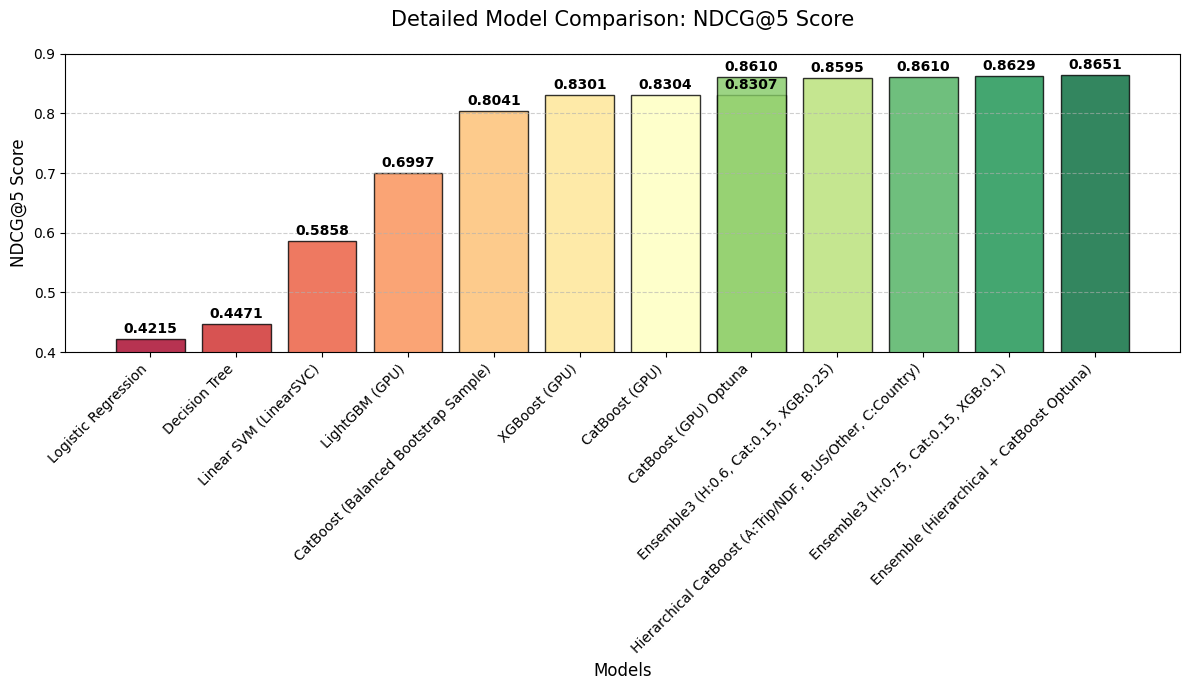

In [264]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_results = pd.DataFrame(results).sort_values("NDCG@5", ascending=True)

plt.figure(figsize=(12, 7))

colors = plt.cm.RdYlGn(np.linspace(0, 1, len(df_results)))

bars = plt.bar(df_results["Model"], df_results["NDCG@5"], color=colors, edgecolor='black', alpha=0.8)

plt.ylim(0.4, 0.9) 

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, 
             f'{yval:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.title("Detailed Model Comparison: NDCG@5 Score", fontsize=15, pad=20)
plt.ylabel("NDCG@5 Score", fontsize=12)
plt.xlabel("Models", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Cross-Validation test

In [247]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


For each fold, it trains CatBoost and XGBoost, averages their predictions (70% CatBoost, 30% XGBoost), and measures NDCG@5 on the validation fold to evaluate the ensemble’s performance.

In [249]:
from sklearn.metrics import ndcg_score
from sklearn.preprocessing import LabelBinarizer

ndcg_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train_enc)):
    X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_va = y_train_enc[train_idx], y_train_enc[val_idx]

    
    # Train CatBoost (Optuna params)
    model_cat = CatBoostClassifier(
        **study.best_params,
        loss_function="MultiClass",
        task_type="GPU",
        verbose=0,
        random_state=42
    )
    model_cat.fit(X_tr, y_tr)
    proba_cat = model_cat.predict_proba(X_va)
    
    # Train XGBoost
    model_xgb = XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        tree_method="gpu_hist",
        predictor="gpu_predictor",
        random_state=42
    )
    model_xgb.fit(X_tr, y_tr)
    proba_xgb = model_xgb.predict_proba(X_va)
    
    # Simple ensemble (no hierarchy to simplify CV)
    proba_ens = 0.7*proba_cat + 0.3*proba_xgb
    
    lb = LabelBinarizer()
    y_va_bin = lb.fit_transform(y_va)
    
    ndcg = ndcg_score(y_va_bin, proba_ens, k=5)
    ndcg_scores.append(ndcg)
    
    print("NDCG@5:", ndcg)


C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:24:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:24:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:2676: UserWarning: [13:24:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA inst

NDCG@5: 0.8303162972751761


C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:24:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:24:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:2676: UserWarning: [13:24:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA inst

NDCG@5: 0.8301871504169099


C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:24:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:24:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:2676: UserWarning: [13:24:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA inst

NDCG@5: 0.8304800369238506


C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:25:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:25:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:2676: UserWarning: [13:25:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA inst

NDCG@5: 0.8305611151693345


C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:25:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:25:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ralma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:2676: UserWarning: [13:25:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA inst

NDCG@5: 0.8308470814042145


In [250]:
print("Mean NDCG@5:", np.mean(ndcg_scores))
print("Std NDCG@5 :", np.std(ndcg_scores))


Mean NDCG@5: 0.8304783362378971
Std NDCG@5 : 0.0002253326648707359


In [251]:
results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.2964090791970205,
  'Macro_F1': 0.07069365279788577,
  'Weighted_F1': 0.35318365825343645,
  'Macro_Recall': 0.1287337535495786,
  'Top5_Accuracy': np.float64(0.5527628774214706),
  'NDCG@5': 0.4215418019346394},
 {'Model': 'Linear SVM (LinearSVC)',
  'Accuracy': 0.44747136398772575,
  'Macro_F1': 0.07904531383460425,
  'Weighted_F1': 0.42368372666218274,
  'Macro_Recall': 0.11148320133169783,
  'Top5_Accuracy': np.float64(0.7109695251926635),
  'NDCG@5': 0.5858307701505537},
 {'Model': 'Decision Tree',
  'Accuracy': 0.1513667986226605,
  'Macro_F1': 0.04970227103761718,
  'Weighted_F1': 0.22705188042685467,
  'Macro_Recall': 0.11185684822179139,
  'Top5_Accuracy': np.float64(0.7472066711953339),
  'NDCG@5': 0.4470692776353646},
 {'Model': 'XGBoost (GPU)',
  'Accuracy': 0.6492937621512731,
  'Macro_F1': 0.10712520122041146,
  'Weighted_F1': 0.6008301633441735,
  'Macro_Recall': 0.11386962927520956,
  'Top5_Accuracy': np.float64(0.957906

In [265]:
# Feature importance from best_cat (Optuna CatBoost)
import pandas as pd

feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": best_cat.get_feature_importance()
}).sort_values("importance", ascending=False).reset_index(drop=True)

feat_imp.head(20)


,feature,importance
0,age_group,12.021081
1,age,7.357489
2,month_first_active,4.355426
3,month_account_created,3.613201
4,unique_action_types,3.425919
5,signup_method_facebook,3.282479
6,secs_elapsed_min,3.274676
7,signup_flow,3.128866
8,year_account_created,3.084106
9,secs_elapsed_median,2.850355


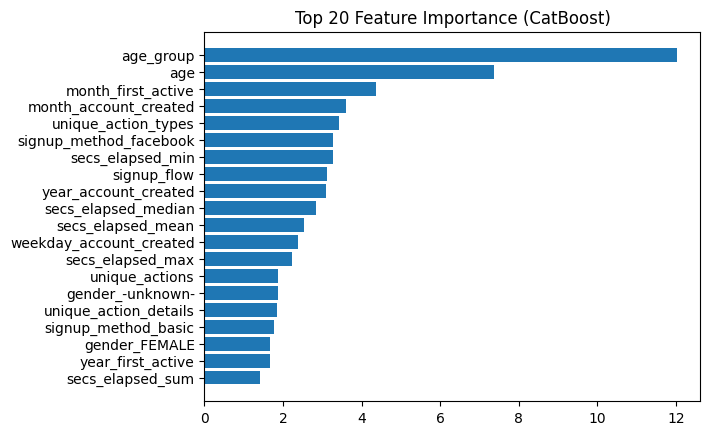

In [266]:
import matplotlib.pyplot as plt

top_features = feat_imp.head(20)

plt.figure()
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importance (CatBoost)")
plt.show()


# Conclusion

## 1. Project Objective

Predict the first destination country a new Airbnb user will book, using user demographics, signup data, and session behavior (such as actions, devices, and time spent).

## 2. Data and Preprocessing

**Data sources:**  
- `train_users`, `test_users`: demographics, signup info, dates, language, devices  
- `sessions`: actions, action types, action details, device types, seconds elapsed

**Main preprocessing steps:**  
- Sessions: dropped null `user_id`, filled missing `action`/`action_type`/`action_detail` (mode per action), filled `secs_elapsed` with median  
- Users: merged with per-user session aggregates (action counts, most frequent values, unique counts, secs stats)  
- Age: corrected year-vs-age, capped at 90, created `age_group`, filled missing with median (33)  
- Categoricals: grouped rare values into "Other", added `not_English`, added date features (year, month, weekday, business day, holiday)  
- Encoding: one-hot for categoricals, MinMax for continuous  
- Train/val split: stratified; target and ID excluded from features

## 3. Class Imbalance

- NDF (~58%) and US (~26%) dominate  
- Other classes (FR, AU, ES, DE, CA, IT, GB, PT, NL, other) are minorities  
- Accuracy is misleading—NDCG@5 and Macro F1 are more informative

## 4. Models and Results Summary

| Model                                   | Accuracy | Macro F1 | Top-5  | NDCG@5 |
|------------------------------------------|----------|----------|--------|--------|
| Logistic Regression                      | 29.6%    | 7.1%     | 55.3%  | 42.2%  |
| Linear SVM                               | 44.7%    | 7.9%     | 71.1%  | 58.6%  |
| Decision Tree                            | 15.1%    | 5.0%     | 74.7%  | 44.7%  |
| XGBoost                                  | 64.9%    | 10.7%    | 95.8%  | 83.0%  |
| LightGBM                                 | 47.6%    | 11.5%    | 89.6%  | 70.0%  |
| CatBoost                                 | 64.9%    | 10.7%    | 95.9%  | 83.0%  |
| CatBoost Optuna                          | 64.9%    | 10.7%    | 95.9%  | 83.1%  |
| Hierarchical CatBoost                    | 73.1%    | 12.0%    | 95.9%  | 86.1%  |
| Hybrid (SMOTE+Undersample) CatBoost      | 64.3%    | 10.9%    | 95.6%  | 82.7%  |
| Balanced Bootstrap CatBoost              | 61.0%    | 11.4%    | 95.5%  | 80.4%  |
| **Ensemble (Hierarchical + CatBoost O.)**| **74.2%**| **12.3%**|**95.9%**|**86.5%**|

## 5. Main Findings

- **Linear models (Logistic, SVM):** Weak baselines, not competitive.
- **Decision Tree:** Overfits, yields worst accuracy, not recommended.
- **Gradient boosting (XGBoost, CatBoost):** Substantial gains; XGBoost and CatBoost perform similarly; LightGBM underperforms.
- **Optuna tuning:** Provides small but consistent NDCG@5 improvement.
- **Hierarchical approach:** Offers best overall improvement, especially for handling imbalance.
- **Resampling (SMOTE, undersampling, balanced bootstrap):** Boosts Macro F1 but does not beat hierarchical model's accuracy/NDCG@5.
- **Ensembling:** Hierarchical + CatBoost Optuna (70/30 blend) yields best results.
- **5-fold CV:** Mean NDCG@5 ≈ 83.05%, std ≈ 0.0002 — very stable.
- **Feature importance:** Linear model focuses on `gender_-unknown-`, `age_group`, gender; tree models use features more broadly.

## 6. Final Recommendations

1. Use the Ensemble (Hierarchical CatBoost + CatBoost Optuna) as the production model.
2. Optimize for NDCG@5 as the main metric; monitor Macro F1 for minority classes.
3. Keep all session-derived features; future refinement of feature engineering is recommended.
4. Avoid hybrid sampling in the main pipeline; hierarchical modeling outperforms it.
5. Use stratified 5-fold CV for future model evaluations.

## 7. Summary

The hierarchical decomposition combined with gradient boosting and ensembling provides strong performance on this imbalanced 12-class destination prediction task. The final ensemble achieves NDCG@5 of 86.5% and Top-5 accuracy of 95.9%, meaning in most cases the correct country is in the top 5 predictions. Cross-validation confirms these results are stable and generalize well.